In [6]:
from utilityFunctions import load_csv_to_matrix_batch, compute_color_preference_distance_batch, show_heatmaps, compute_color_similarity_distance_batch, compute_correlations, RSA, split_and_average_matrices
from utilityFunctions_GWOT import compute_GWOT_for_all_pairs, GWD_and_plot
import numpy as np
import pickle
import os
import random
import pandas as pd
import matplotlib.pyplot as plt

unique_colours = np.array(['#d2b700', '#db8b08', '#c7512c', '#c13547', '#a03663', '#753a7a', '#4b488e', '#005692', '#006a8b', '#007b75', '#008a52', '#9aa400'])
colour_index = {colour: idx for idx, colour in enumerate(unique_colours)}
matrix_size = len(unique_colours)
response_type = 'similarity'

In [2]:
### GWOT configuration
n_eps = 25 # number of epsilon values tried
eps_range = [0.04, 2] # the range of epsilon searched
epsilons = np.logspace(np.log10(eps_range[0]), np.log10(eps_range[1]), n_eps) # epsilon values

In [3]:
folder_path = 'raw_data/202411_data'
subject_matrices_similarity_raw = load_csv_to_matrix_batch(folder_path, response_type, colour_index, matrix_size)
subject_matrices_similarity_distance = compute_color_similarity_distance_batch(subject_matrices_similarity_raw)

Order of files being loaded:
raw_data/202411_data/subject_01_551325.csv
raw_data/202411_data/subject_02_5a9b20.csv
raw_data/202411_data/subject_03_5eb05d.csv
raw_data/202411_data/subject_04_609c10.csv
raw_data/202411_data/subject_05_60d129.csv
raw_data/202411_data/subject_06_610814.csv
raw_data/202411_data/subject_07_6171f3.csv
raw_data/202411_data/subject_08_65a3ab.csv
raw_data/202411_data/subject_09_65f13c.csv
raw_data/202411_data/subject_10_65f18d.csv
raw_data/202411_data/subject_11_65fa3b.csv
raw_data/202411_data/subject_12_663180.csv
raw_data/202411_data/subject_13_667c6c.csv
raw_data/202411_data/subject_14_667df4.csv
raw_data/202411_data/subject_15_668110.csv
raw_data/202411_data/subject_16_6681ad.csv
raw_data/202411_data/subject_17_66906a.csv
raw_data/202411_data/subject_18_66a502.csv
raw_data/202411_data/subject_19_6734b5.csv


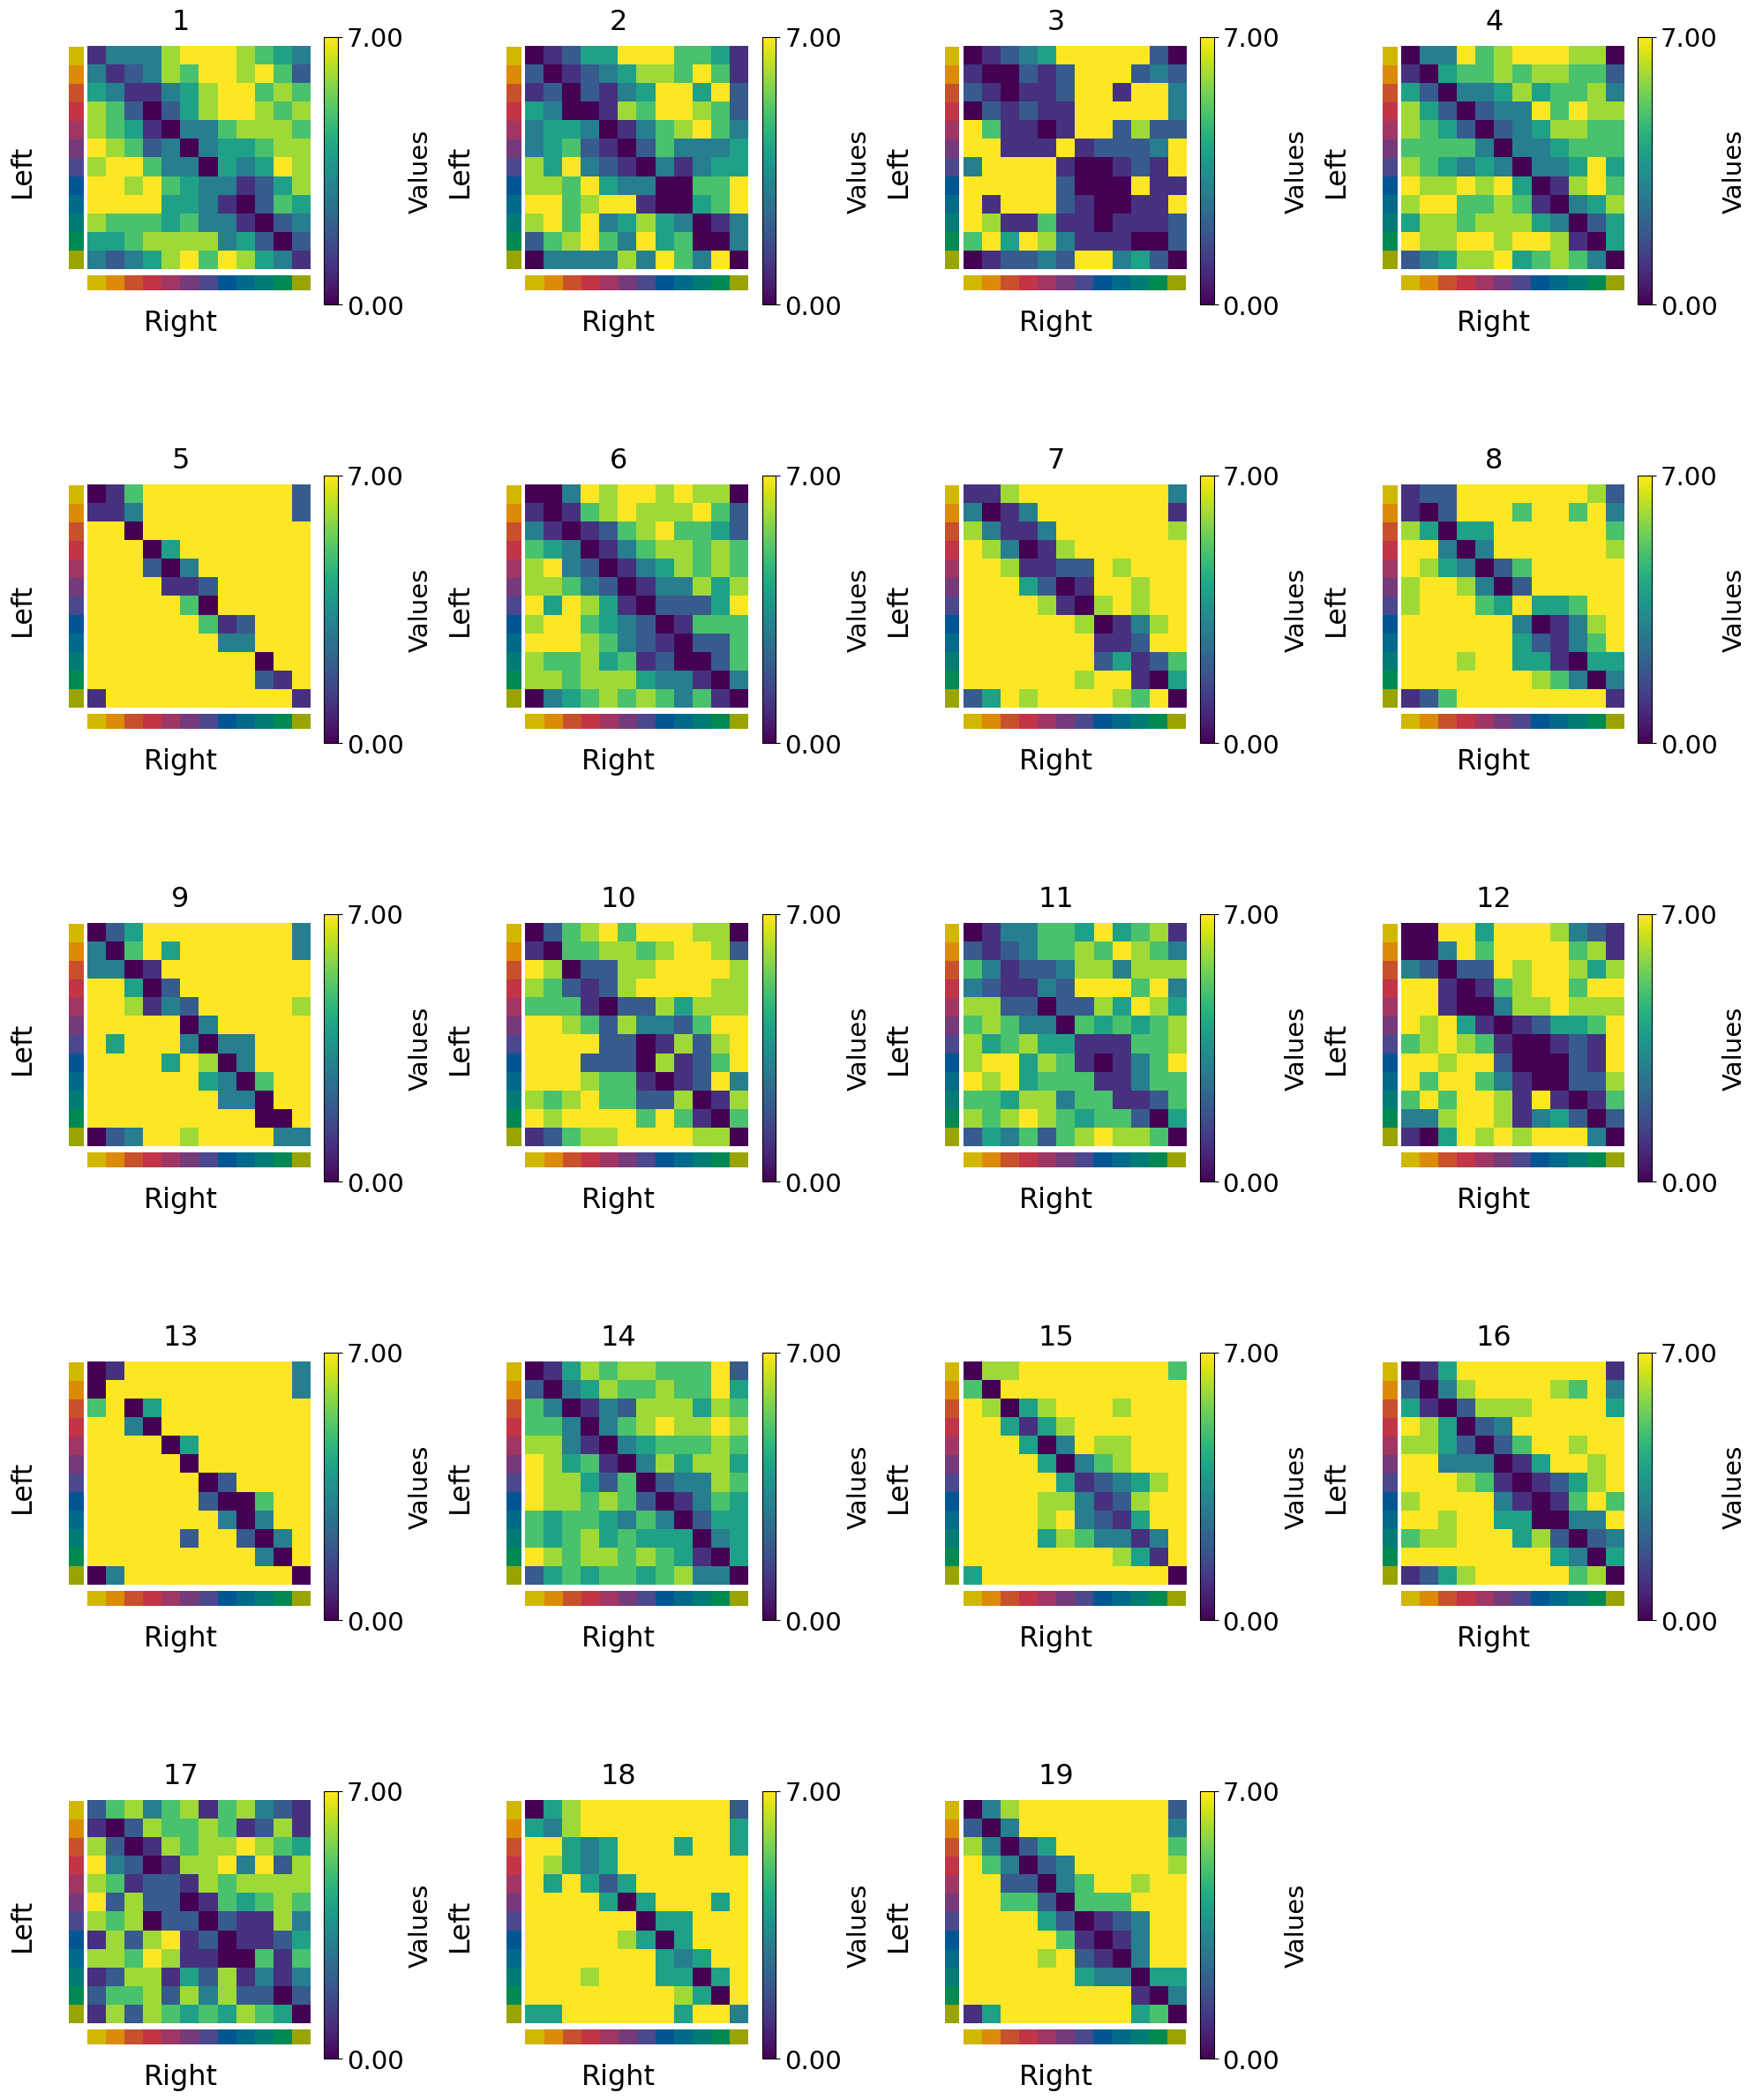

In [4]:
show_heatmaps(vmin_val=0, vmax_val=7, matrices=subject_matrices_similarity_distance, titles=list(range(1, 20)), nrows=5, ncols=4, cmap_name = "viridis", cbar_label="Values", color_labels=unique_colours)

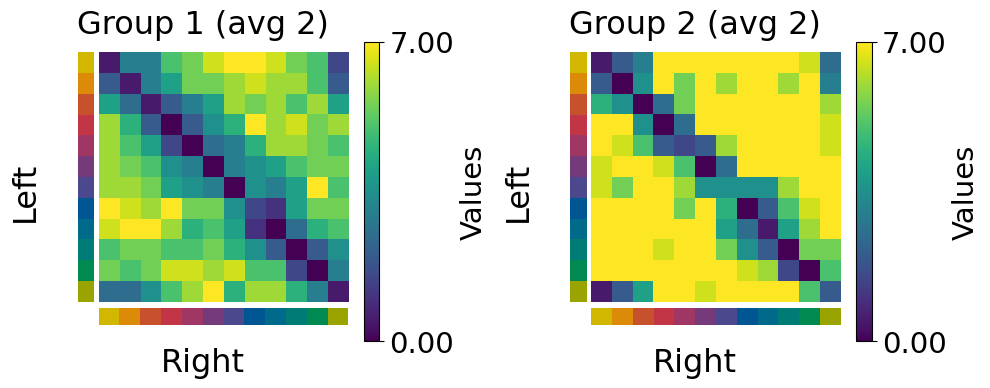

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.8914019321842716, Minimum GWD: 2.939


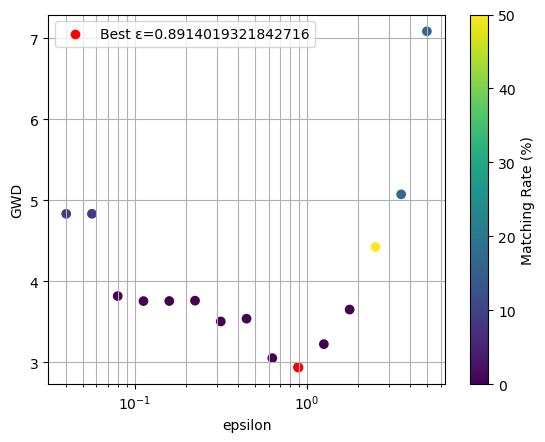

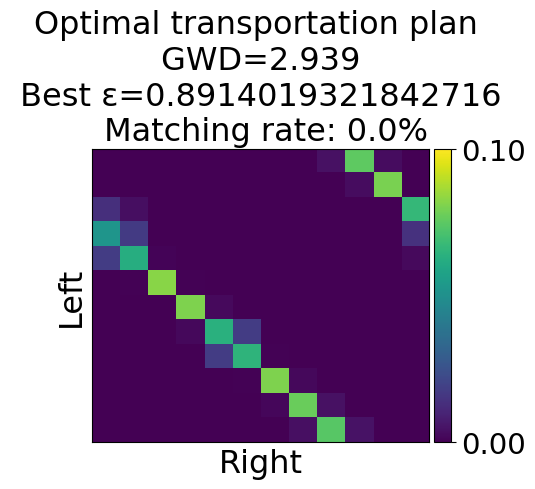

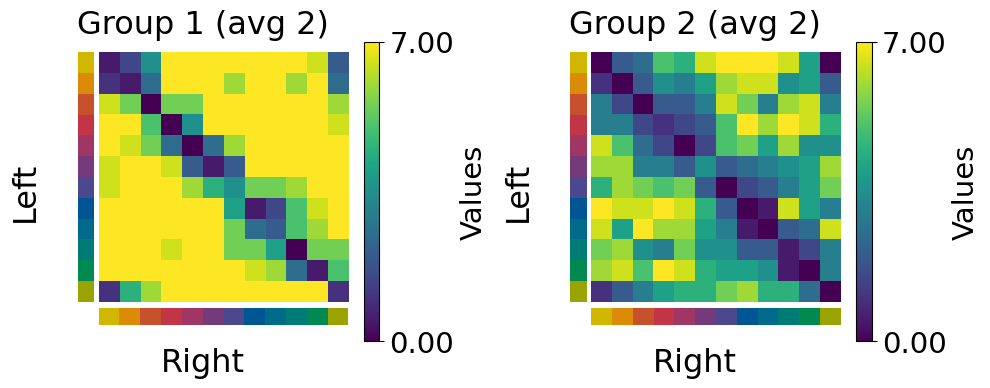

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 1.7767738116582528, Minimum GWD: 6.294


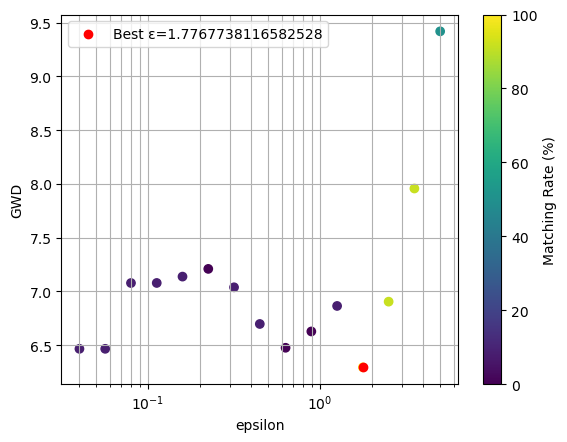

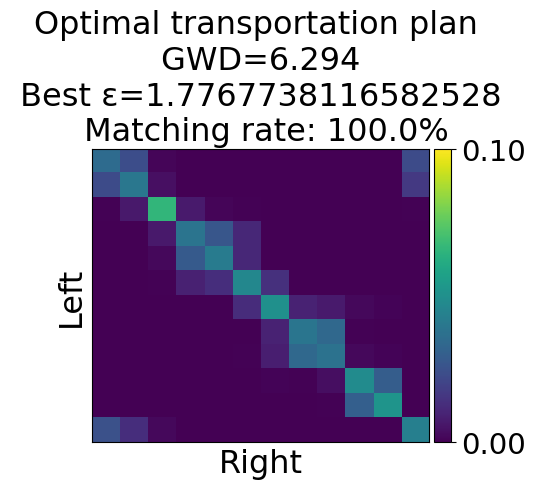

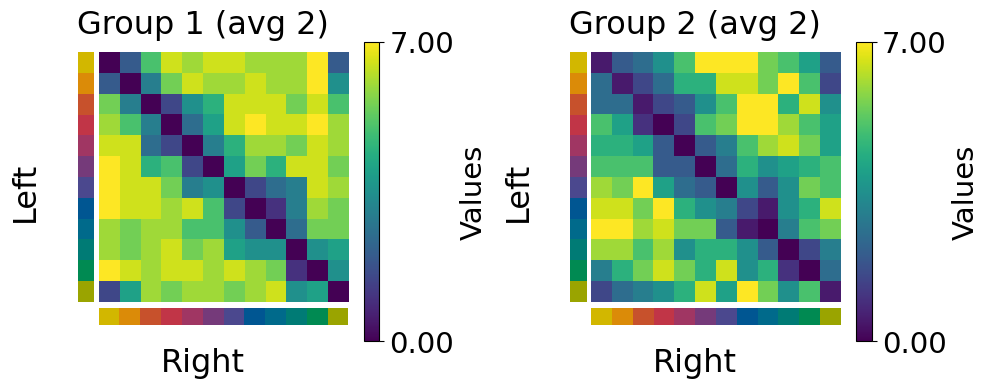

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.15891948094037048, Minimum GWD: 2.063


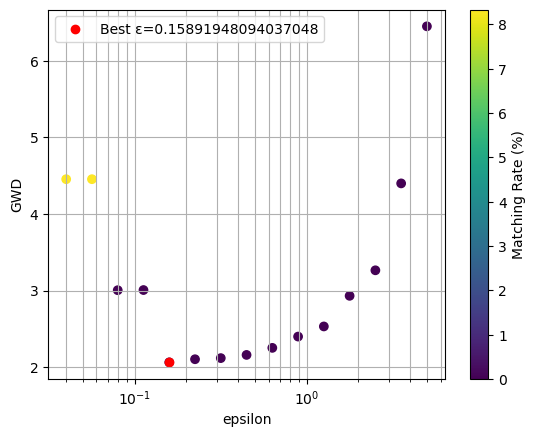

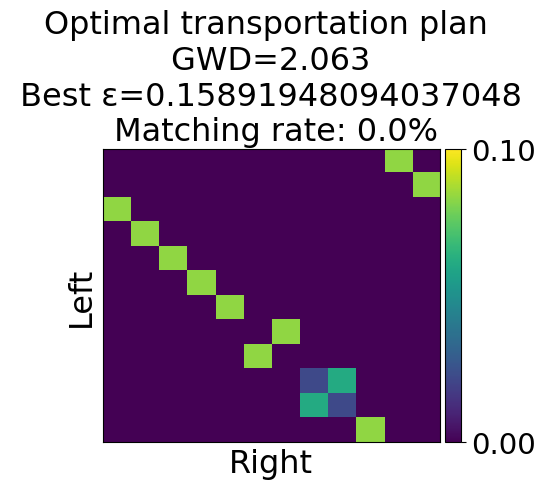

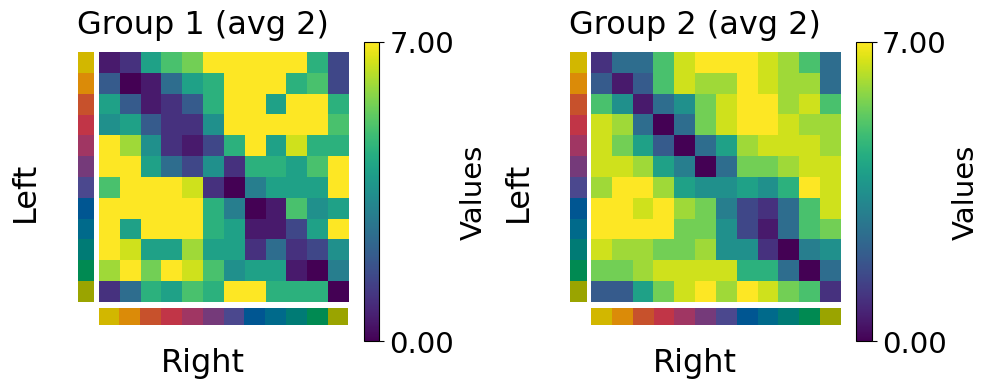

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.04000000000000001, Minimum GWD: 2.241


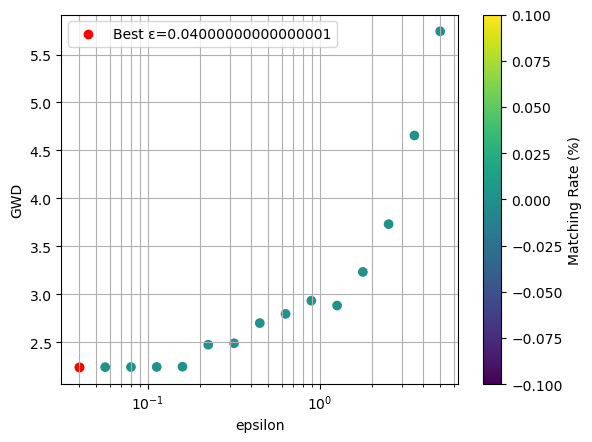

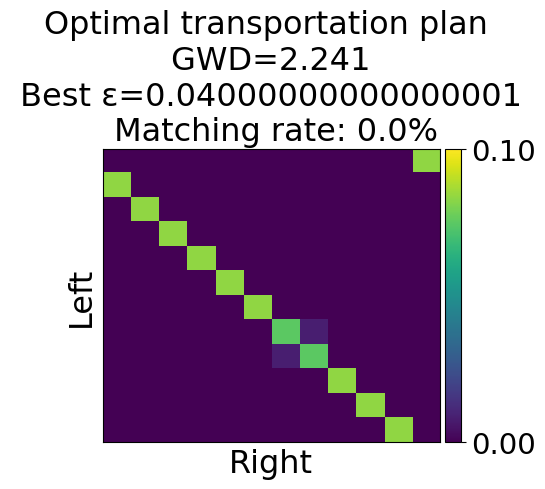

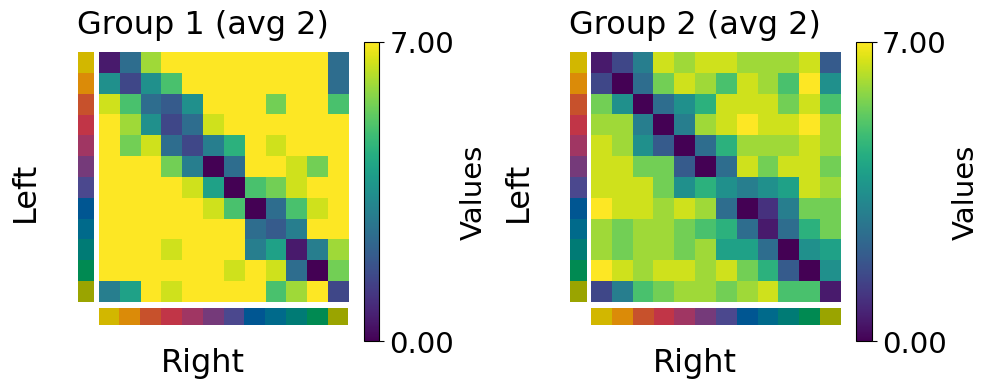

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.6313850355589193, Minimum GWD: 2.907


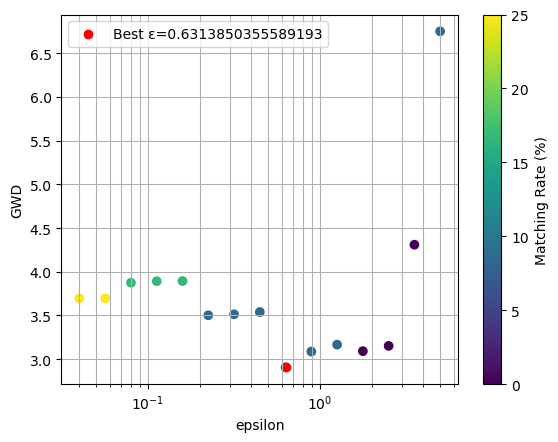

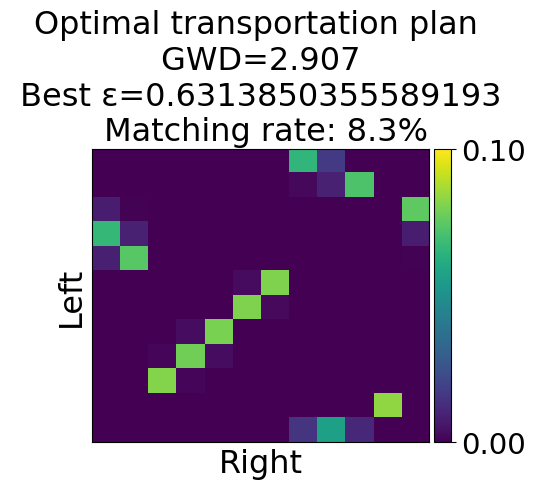

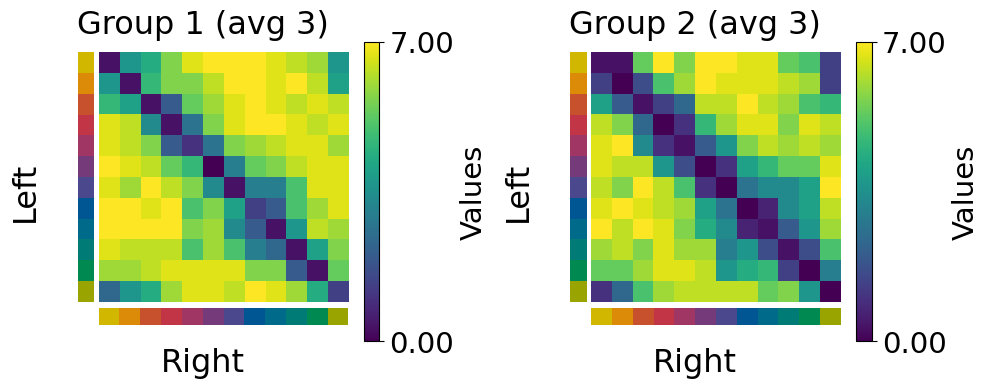

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.22436567925080053, Minimum GWD: 1.907


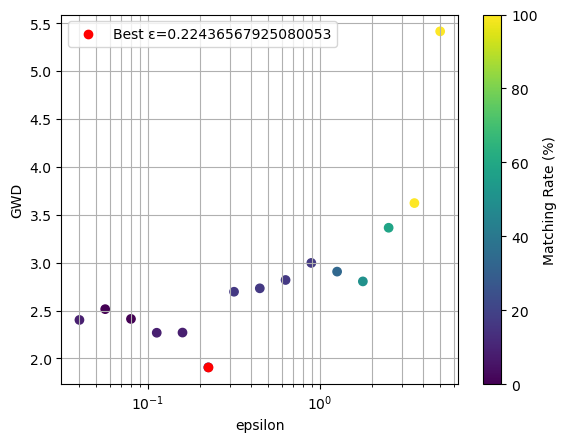

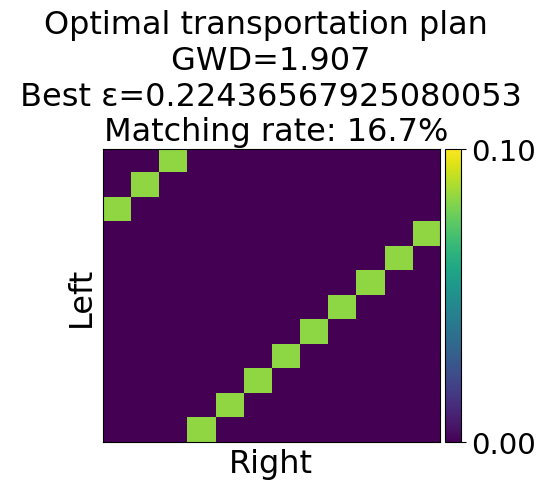

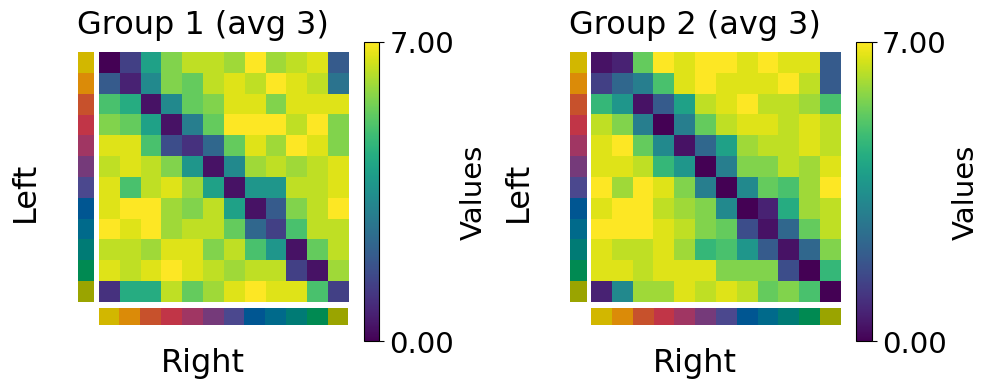

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.07972941262554757, Minimum GWD: 1.372


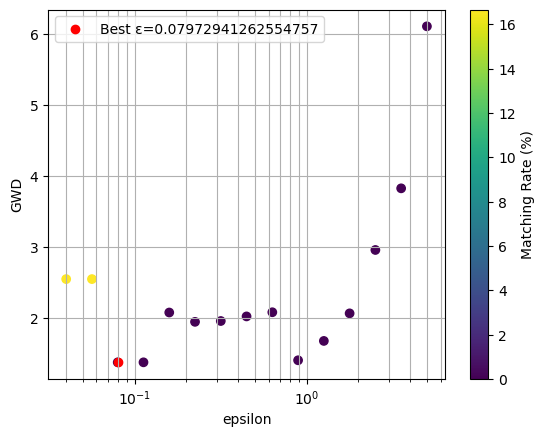

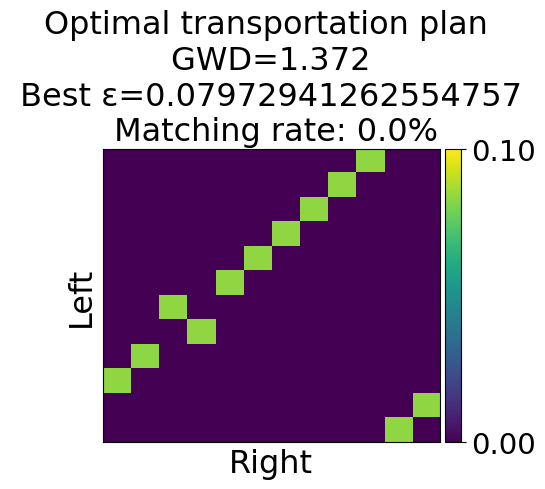

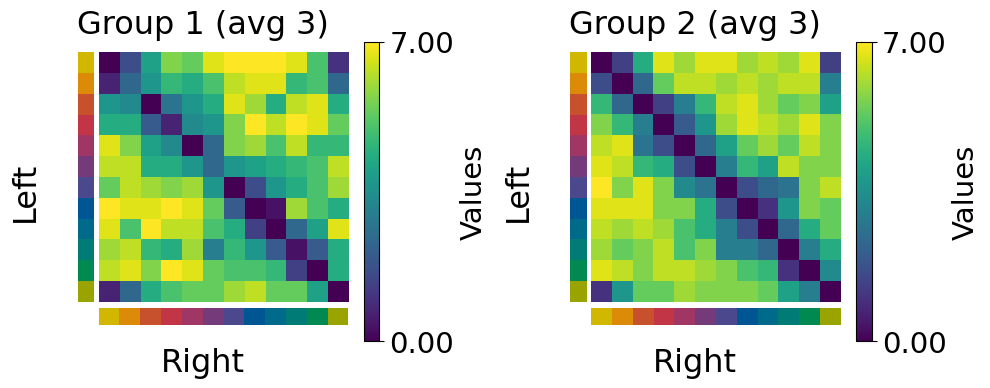

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.1125635681298911, Minimum GWD: 1.718


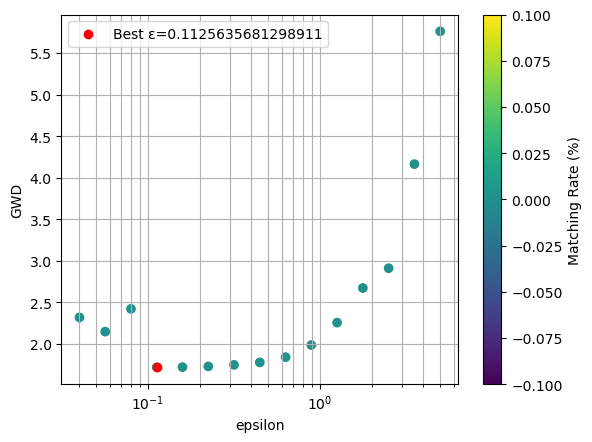

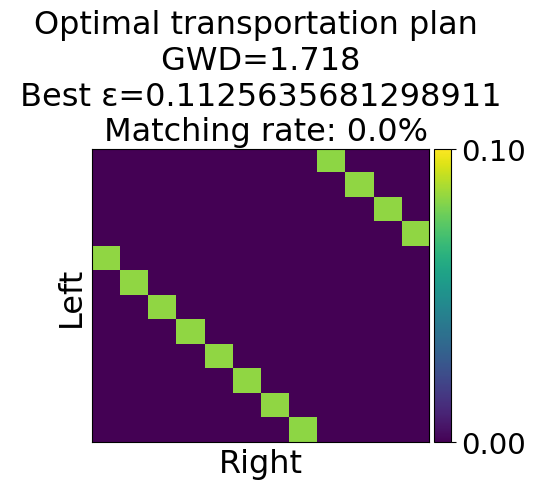

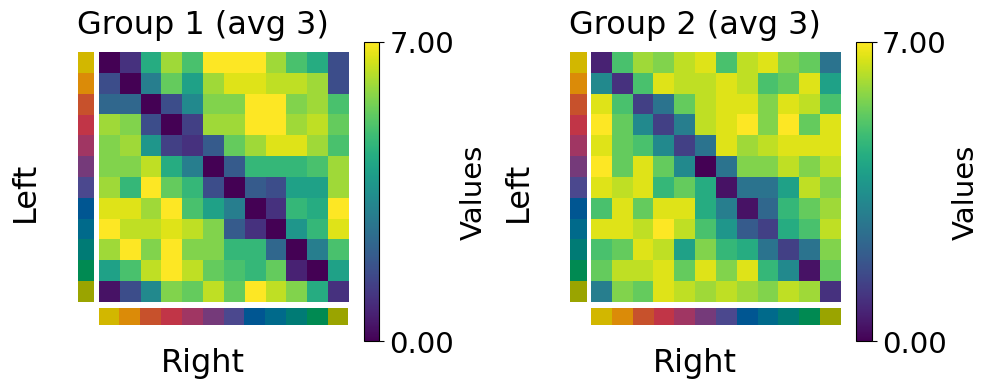

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 1.2584989506418272, Minimum GWD: 2.057


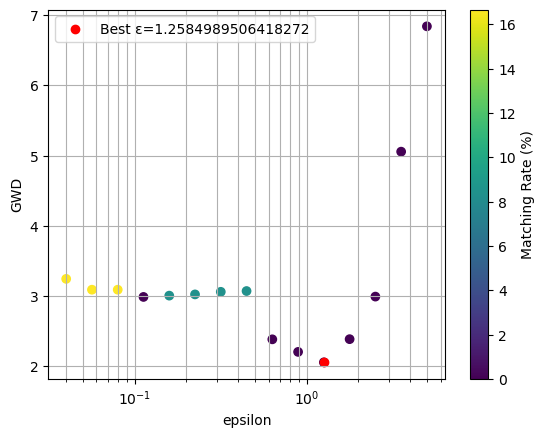

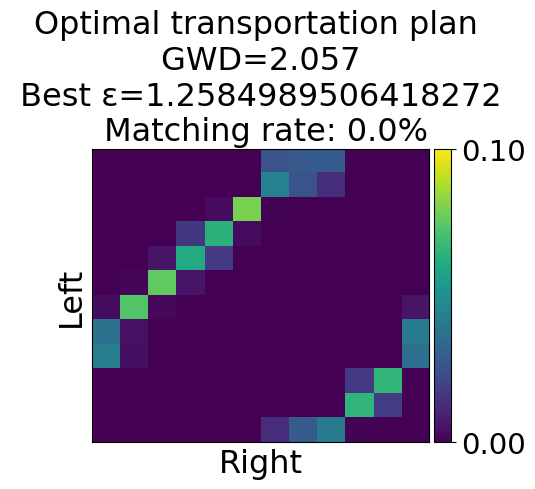

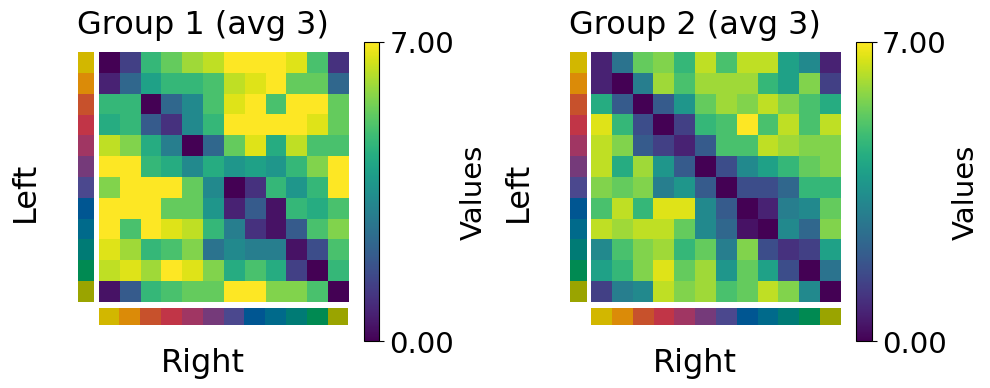

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 1.2584989506418272, Minimum GWD: 2.390


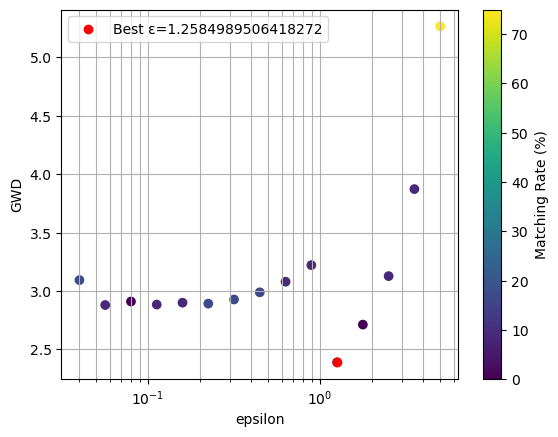

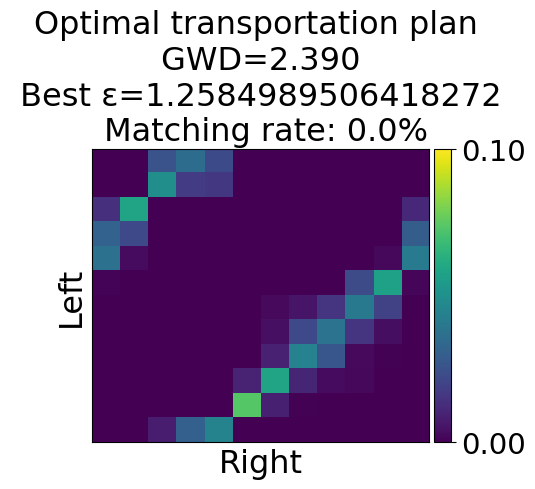

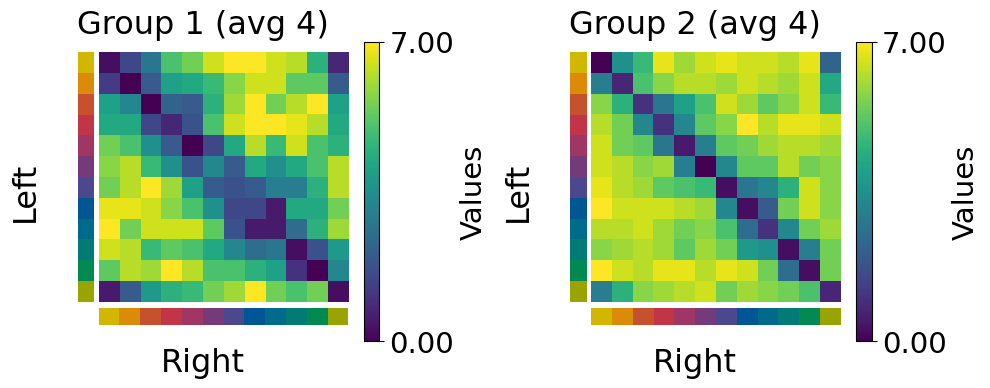

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.15891948094037048, Minimum GWD: 2.134


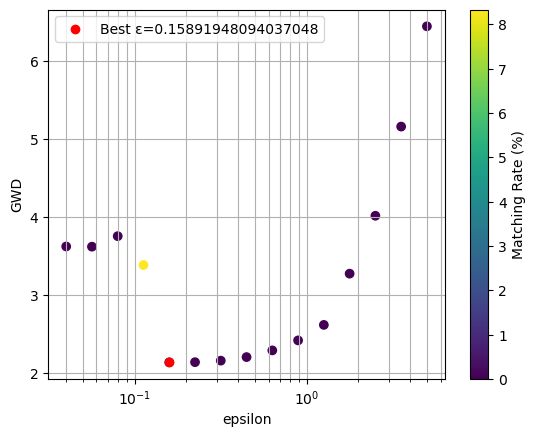

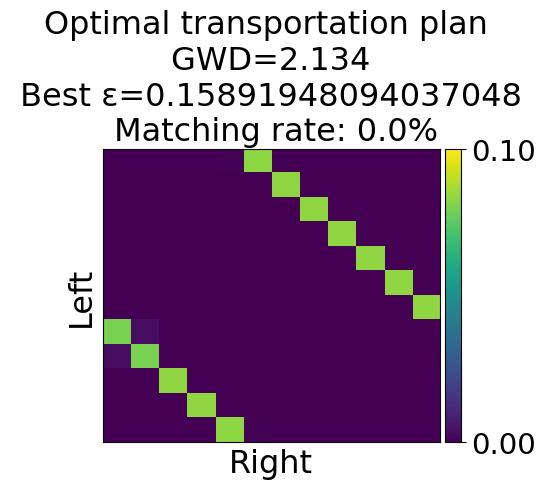

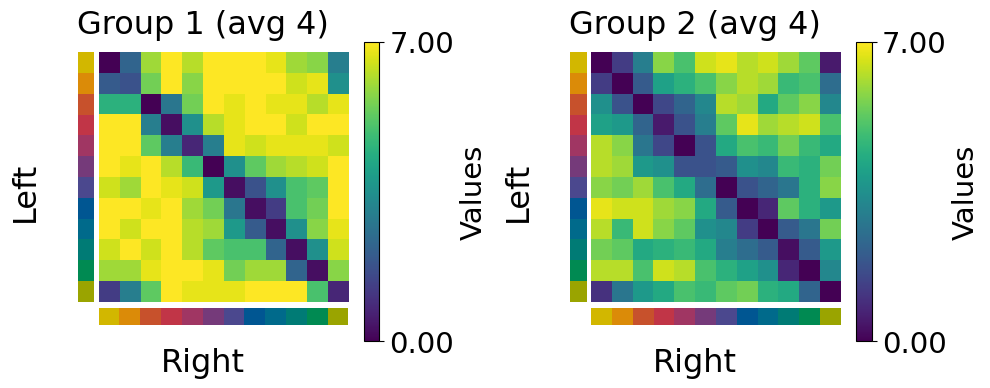

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.8914019321842716, Minimum GWD: 3.272


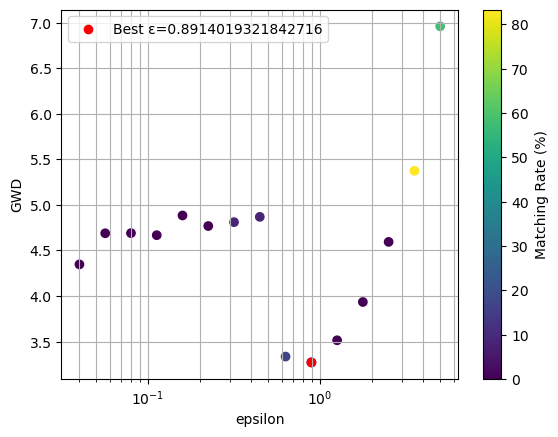

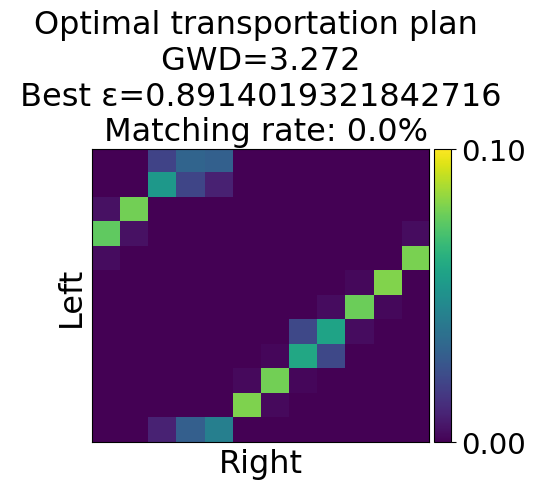

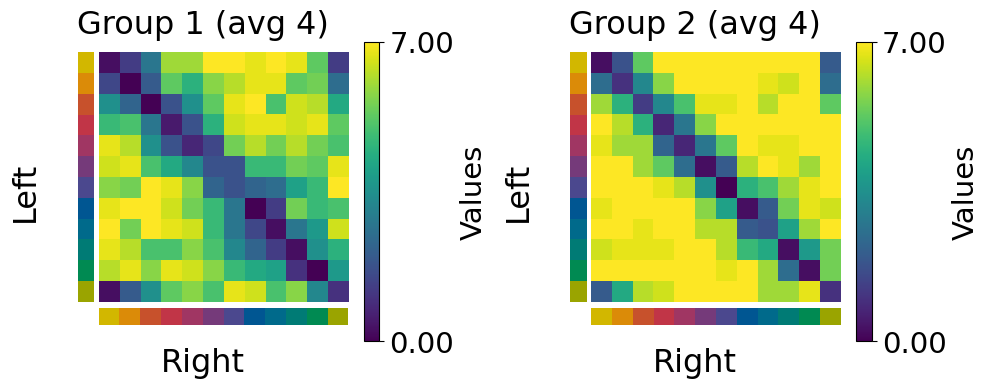

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.6313850355589193, Minimum GWD: 2.373


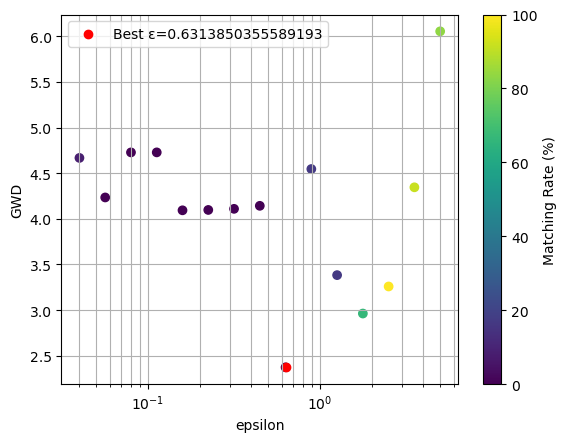

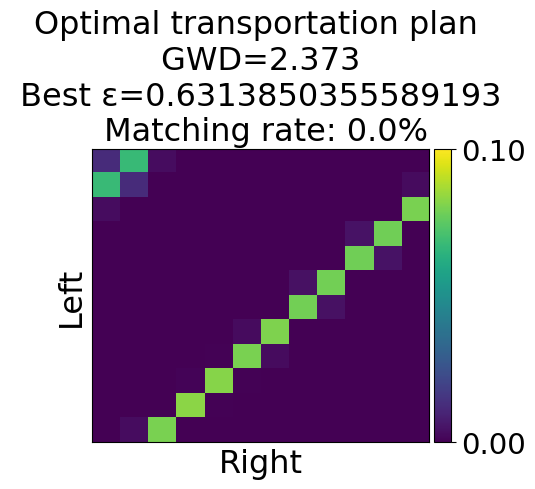

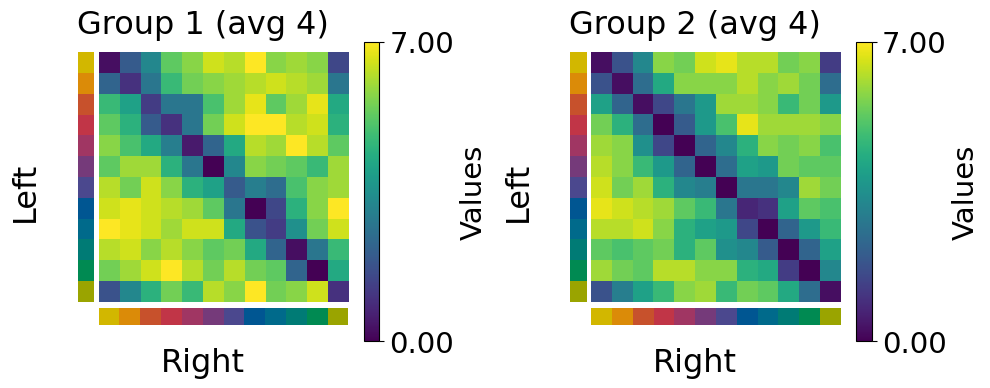

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.447213595499958, Minimum GWD: 1.339


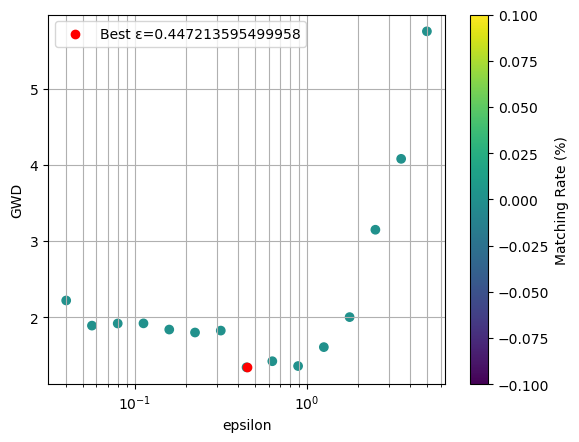

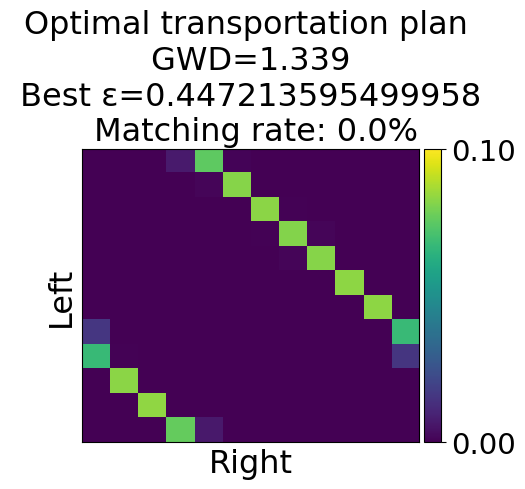

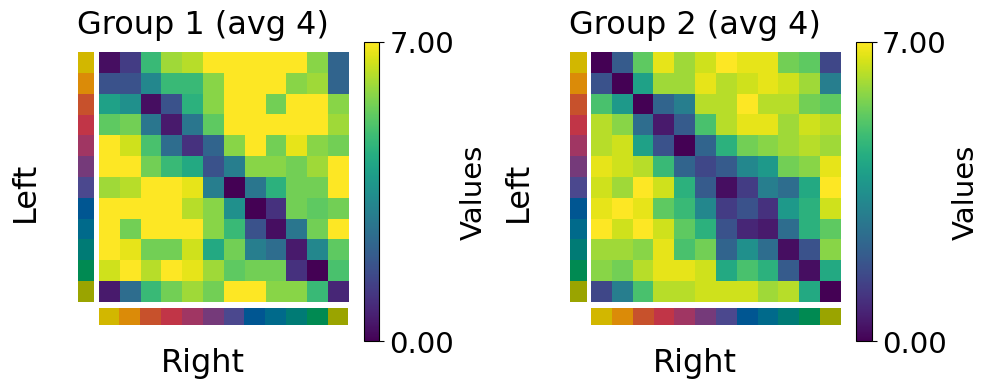

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.31676392175331586, Minimum GWD: 1.540


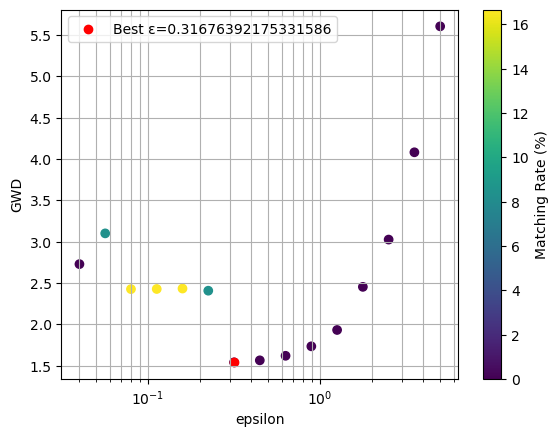

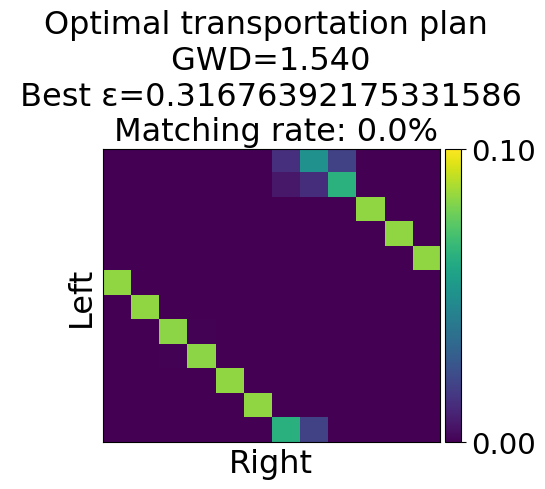

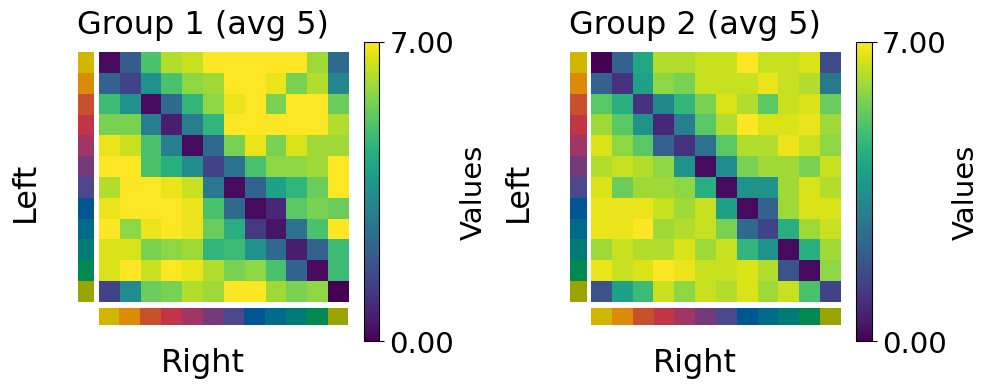

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.6313850355589193, Minimum GWD: 1.291


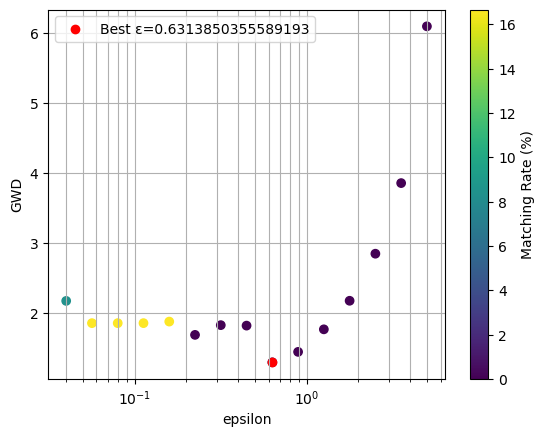

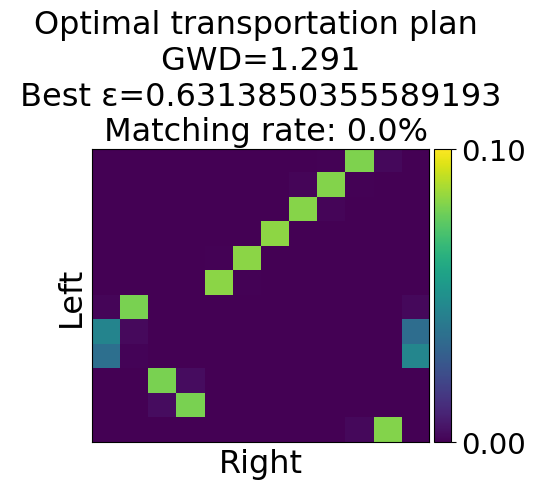

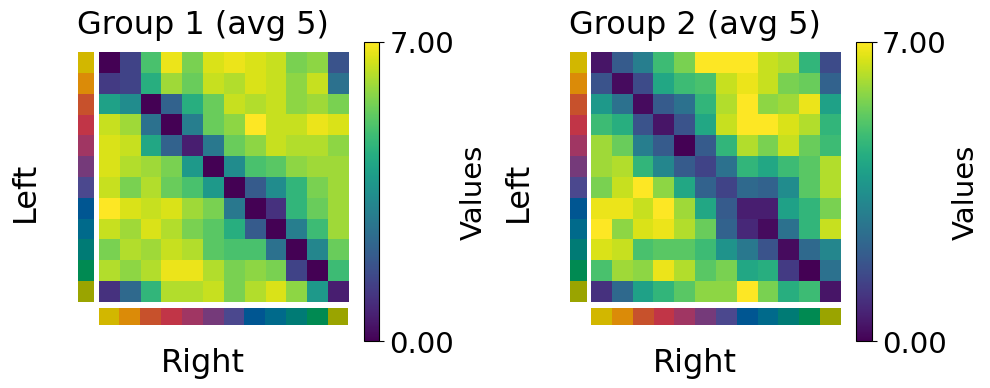

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.31676392175331586, Minimum GWD: 1.509


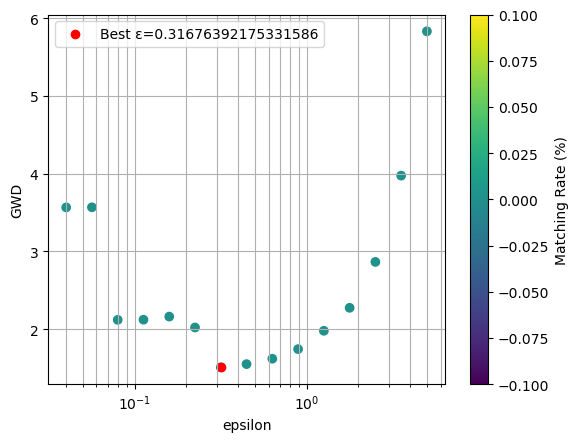

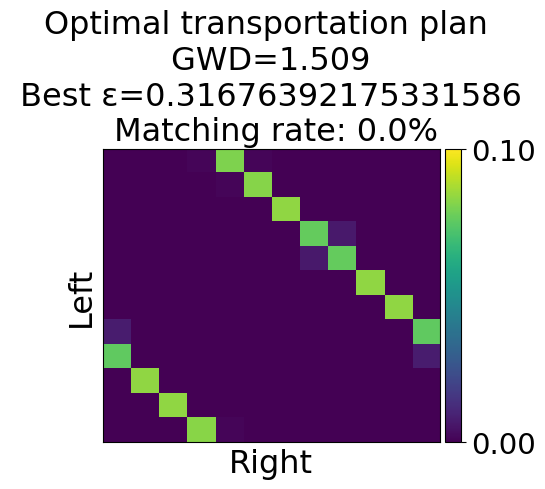

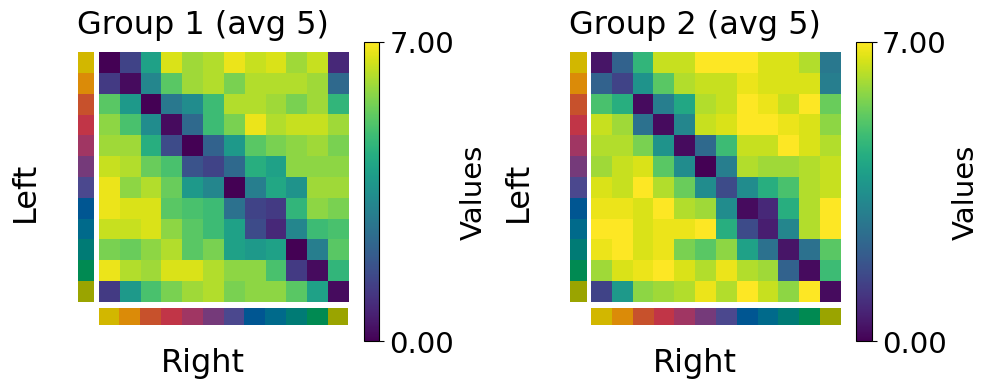

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 1.2584989506418272, Minimum GWD: 1.203


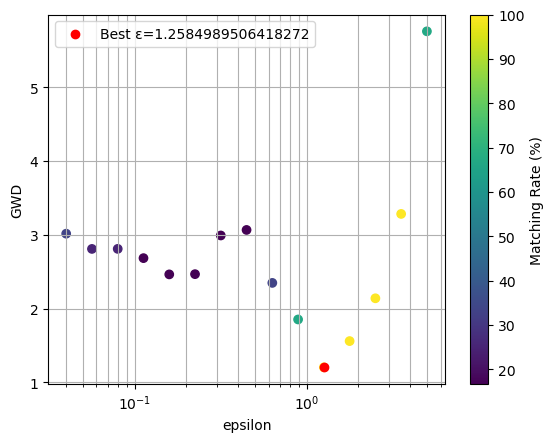

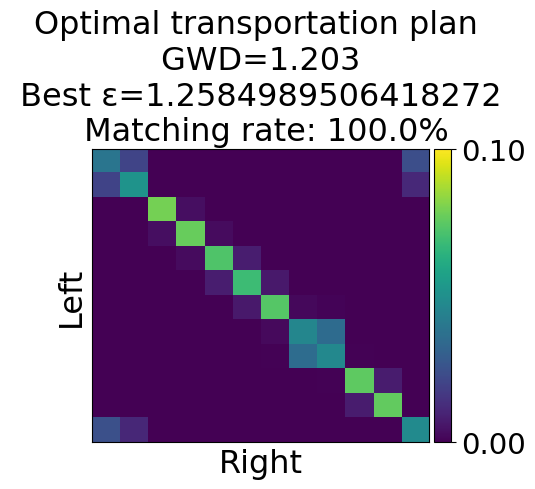

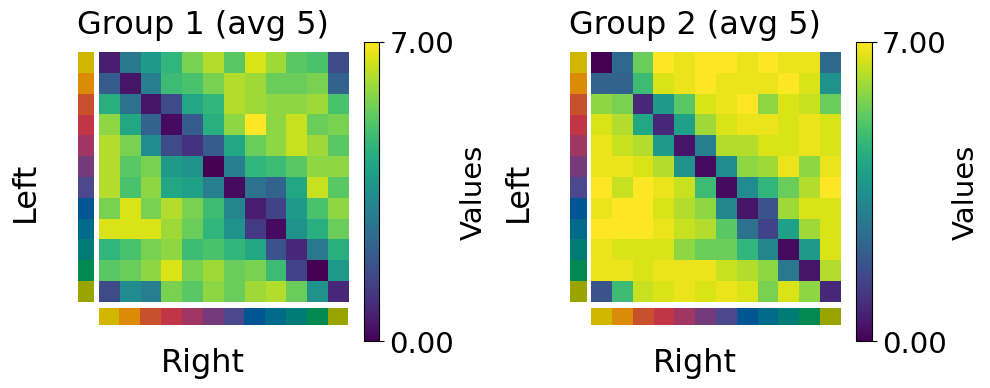

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.8914019321842716, Minimum GWD: 2.565


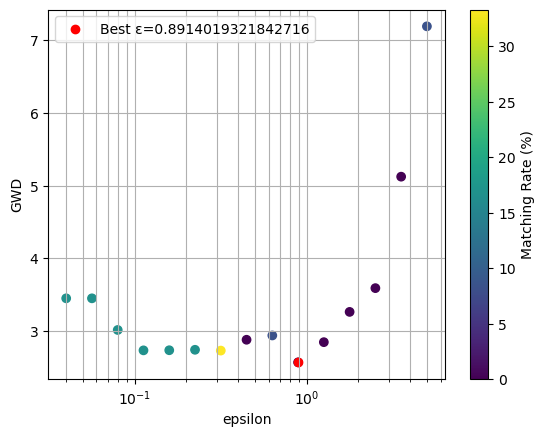

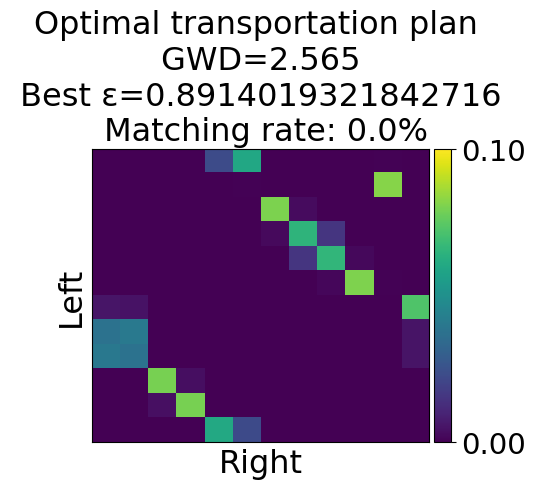

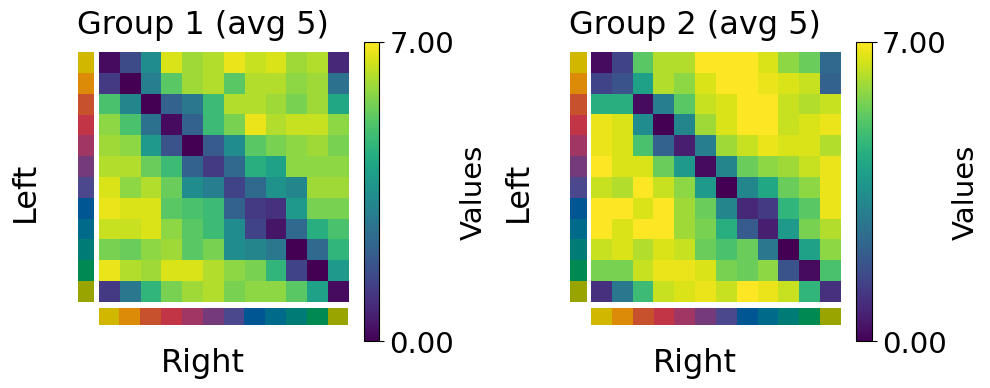

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.15891948094037048, Minimum GWD: 1.414


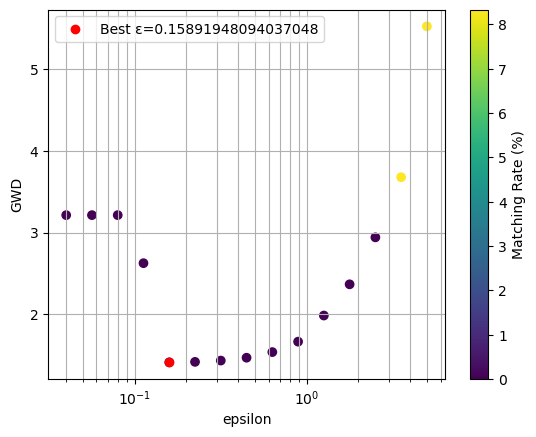

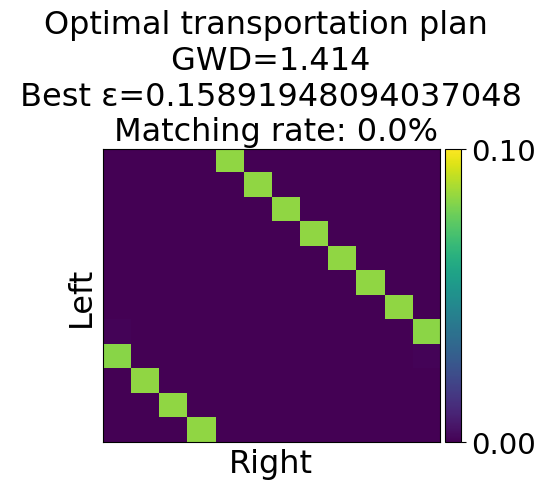

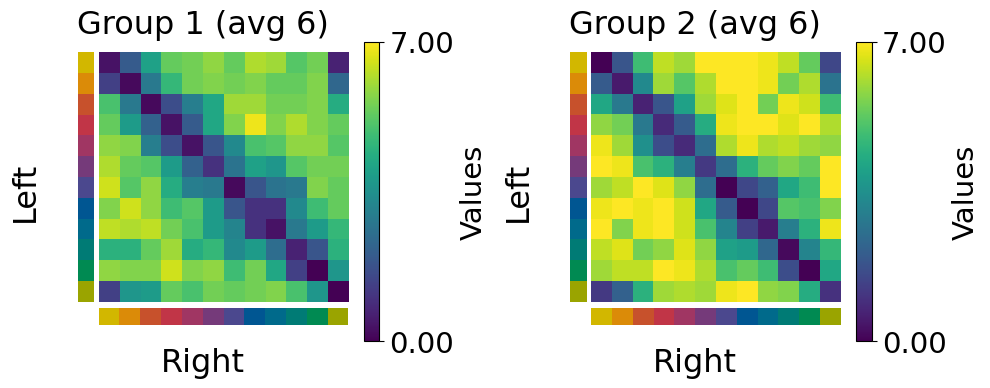

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.1125635681298911, Minimum GWD: 1.498


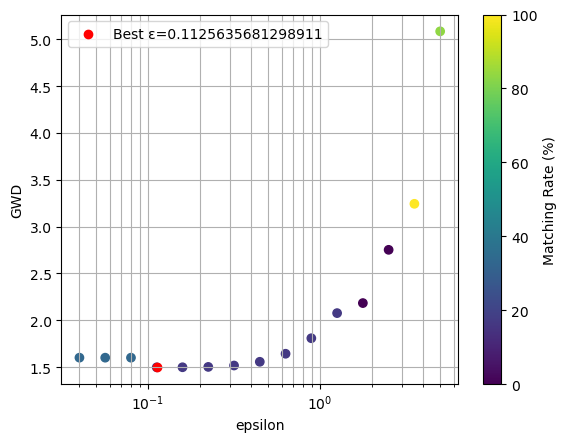

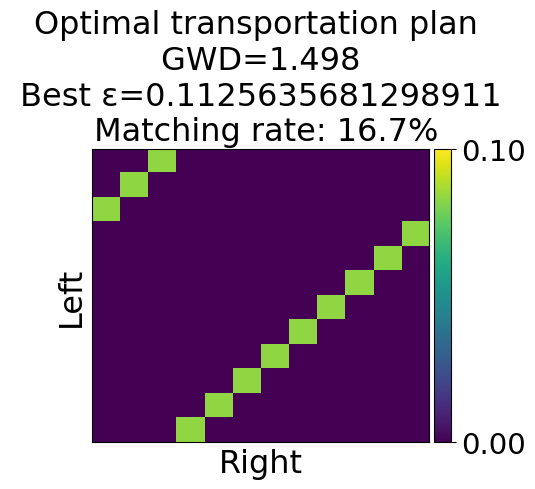

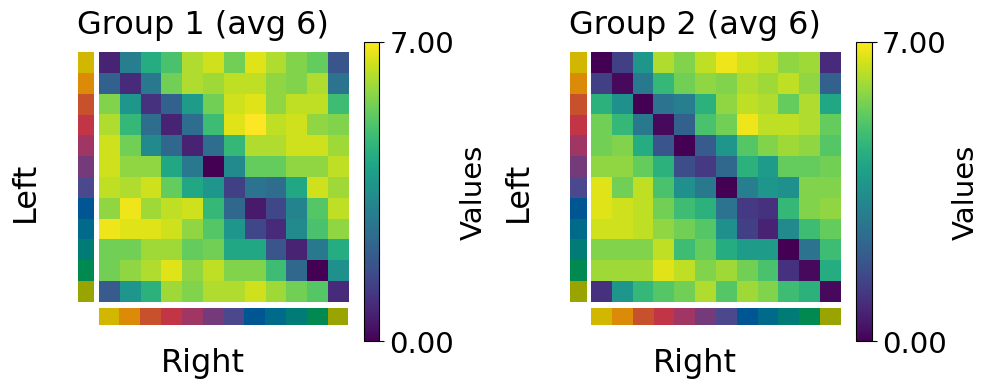

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.447213595499958, Minimum GWD: 0.987


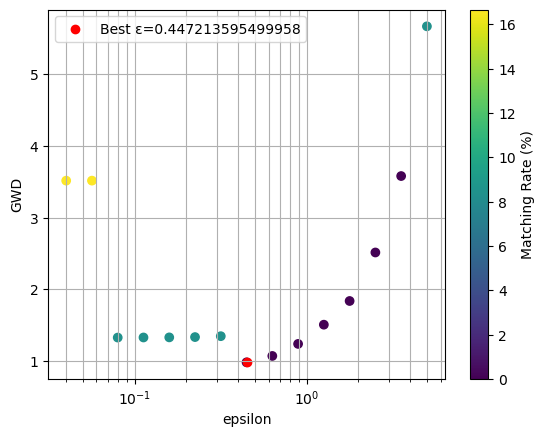

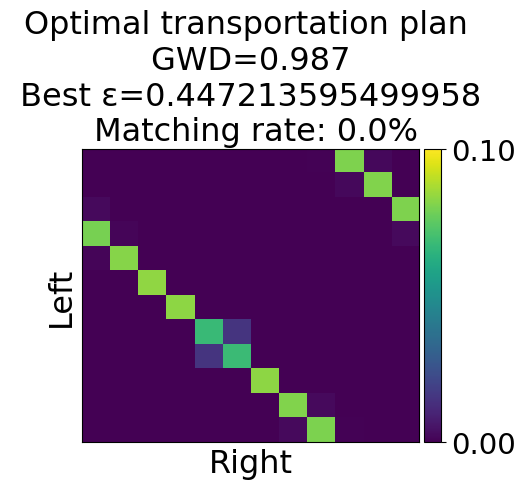

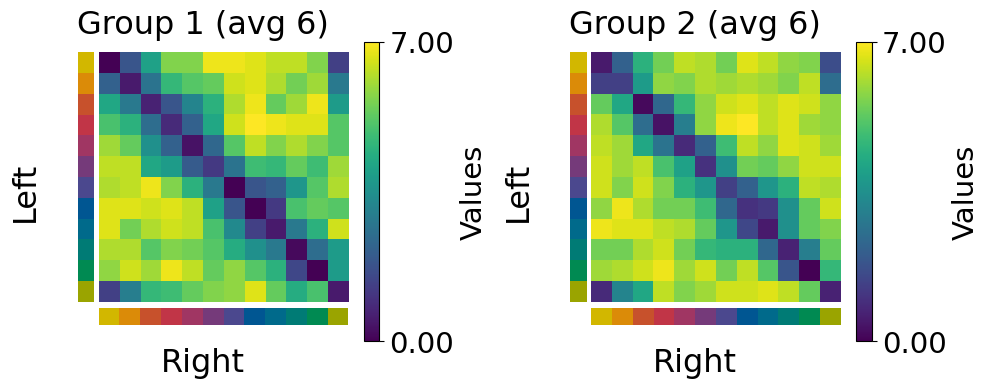

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.447213595499958, Minimum GWD: 1.253


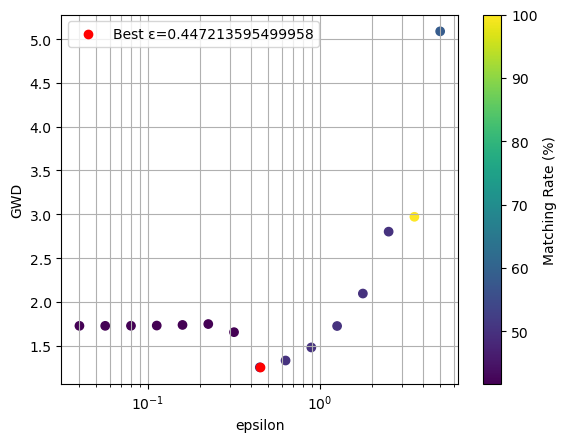

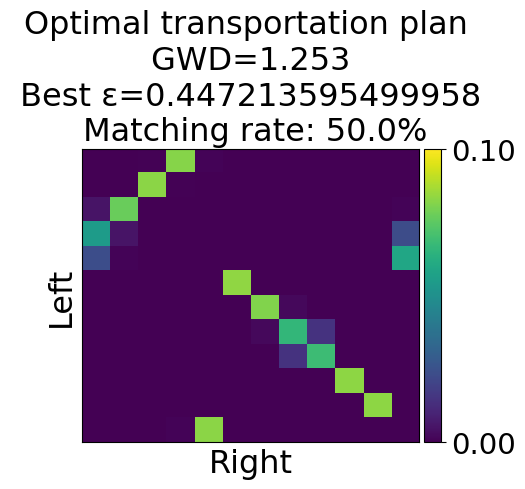

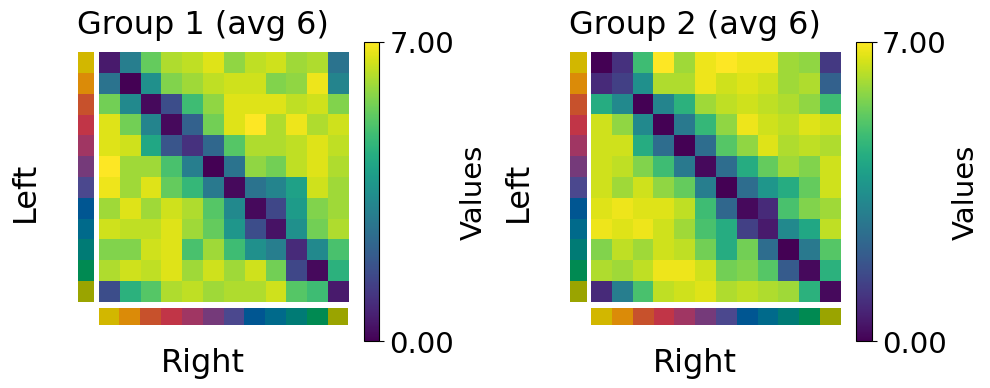

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.8914019321842716, Minimum GWD: 0.778


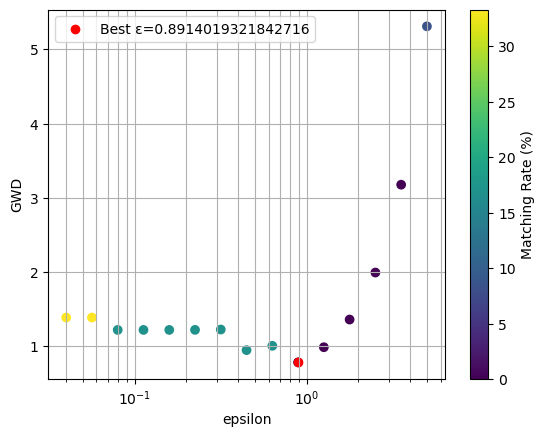

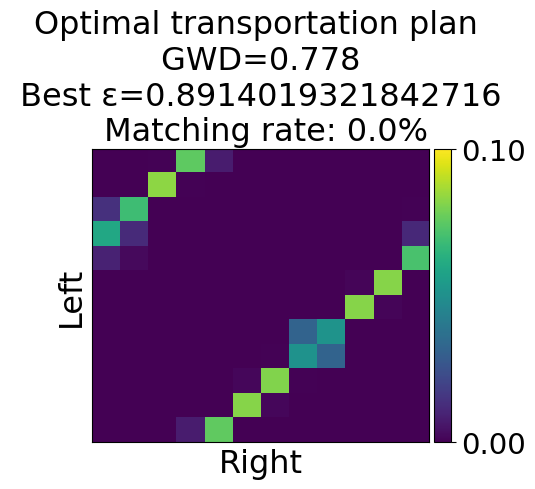

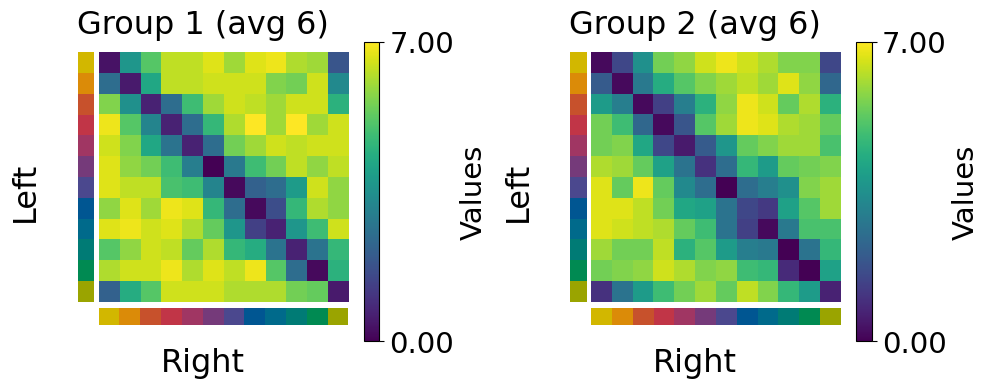

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.6313850355589193, Minimum GWD: 1.339


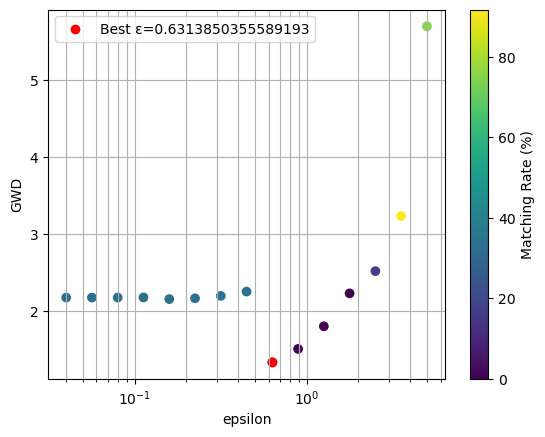

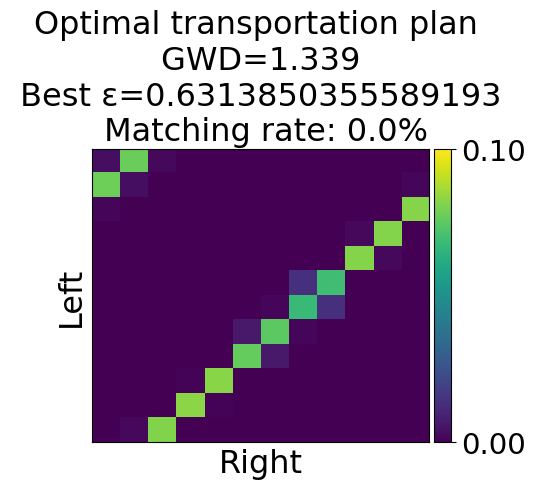

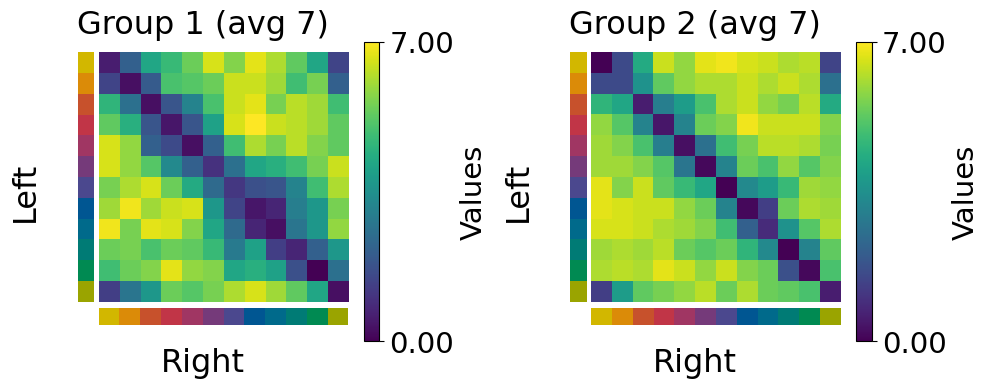

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.447213595499958, Minimum GWD: 1.911


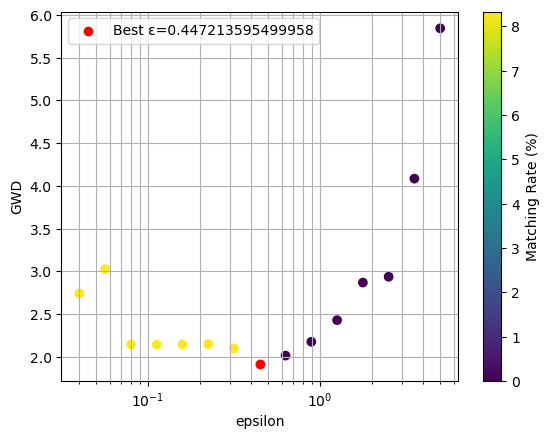

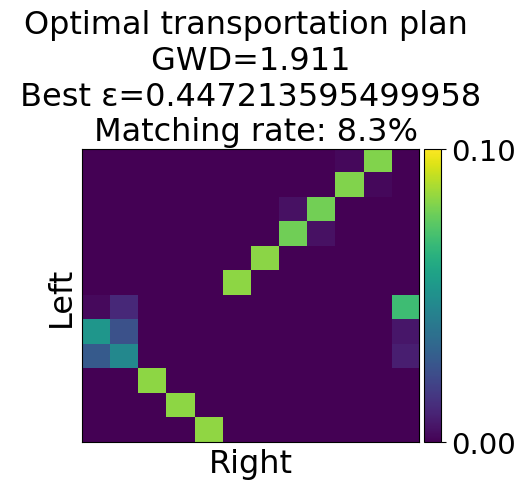

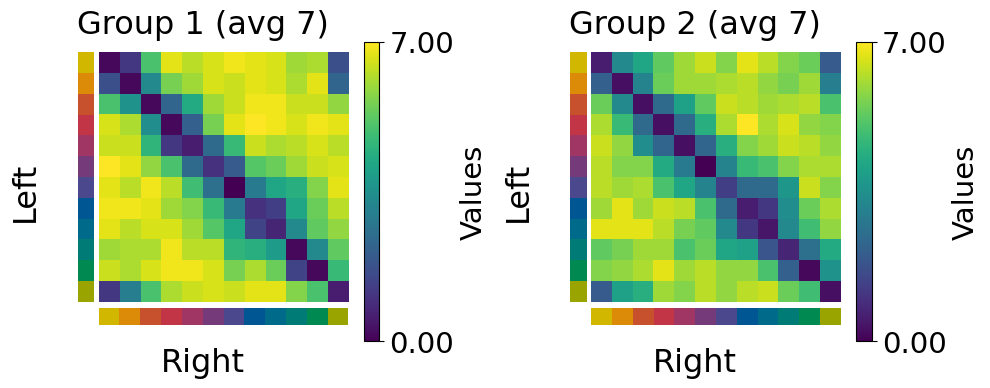

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.05647279437943463, Minimum GWD: 0.442


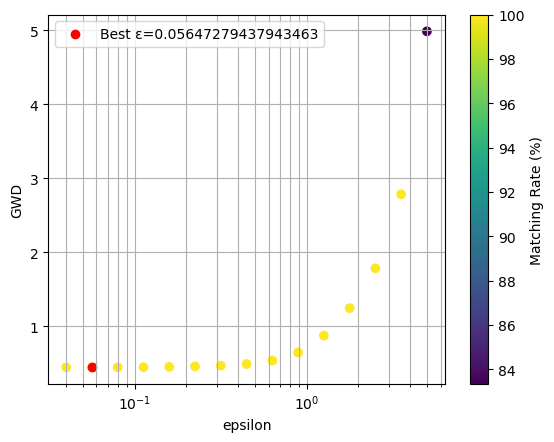

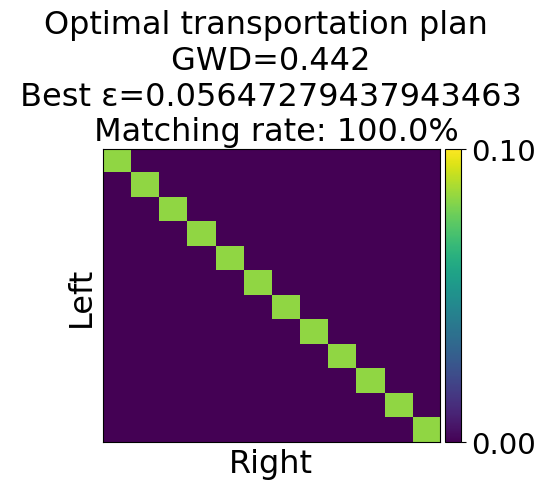

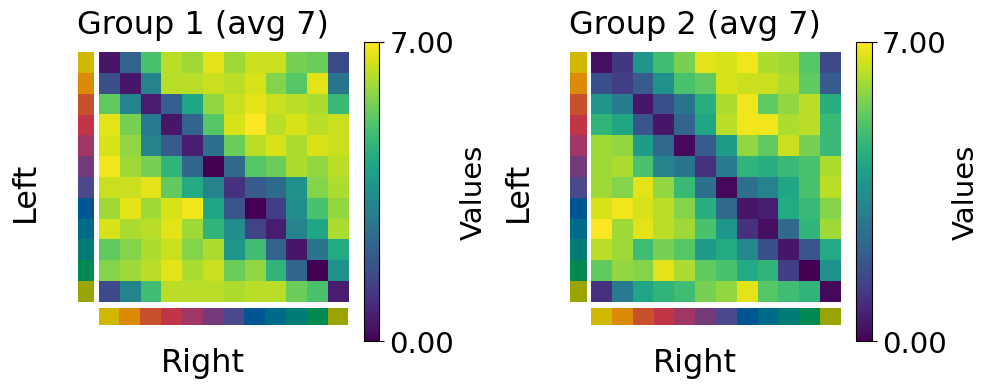

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.1125635681298911, Minimum GWD: 1.717


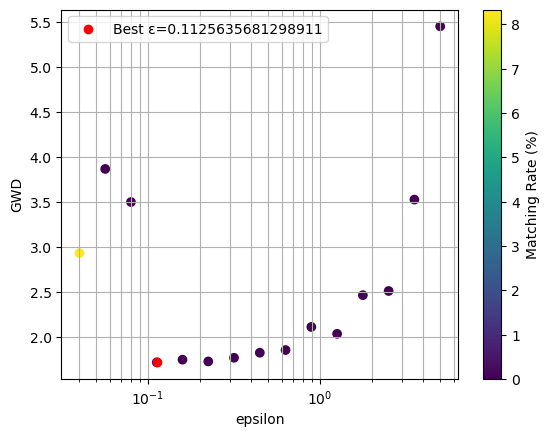

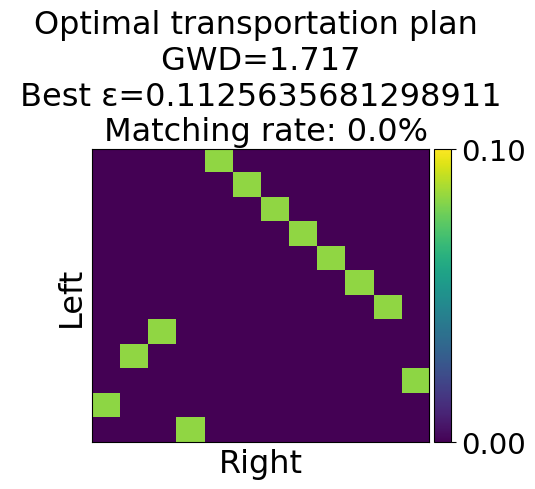

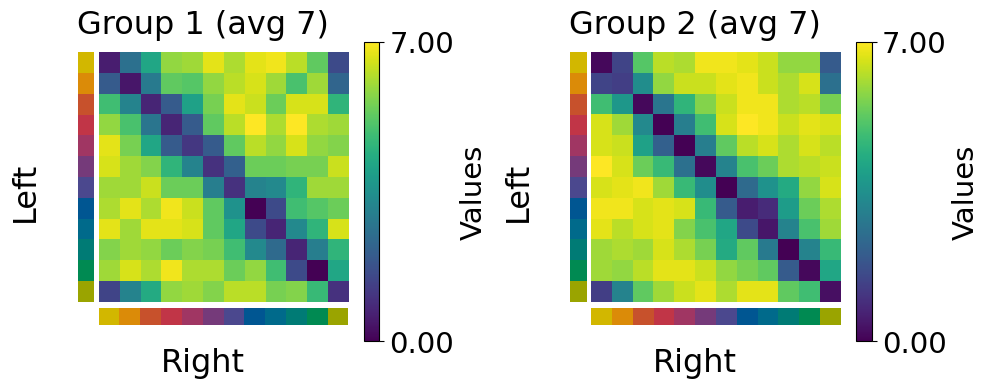

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.15891948094037048, Minimum GWD: 0.665


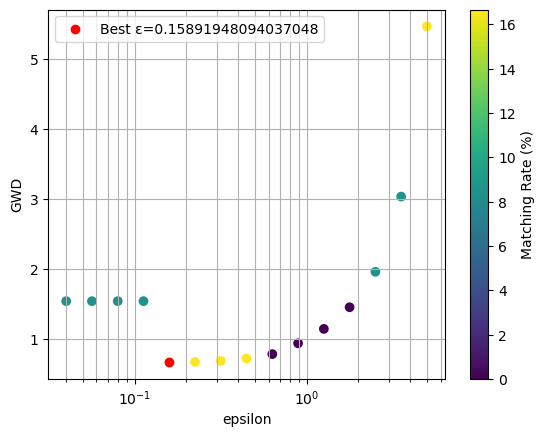

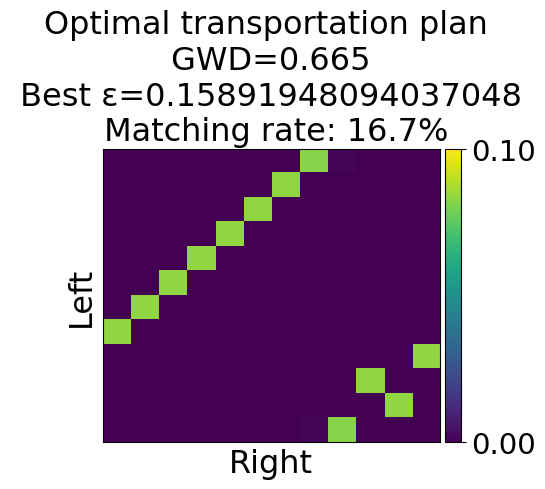

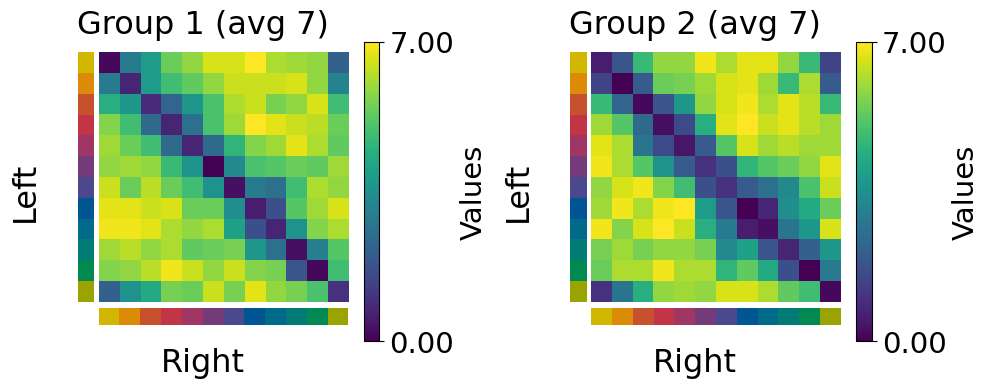

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.05647279437943463, Minimum GWD: 1.657


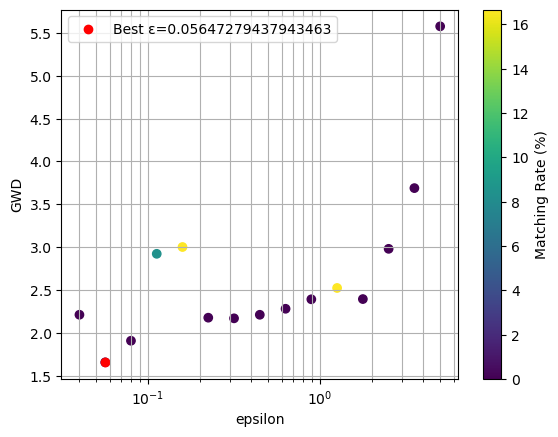

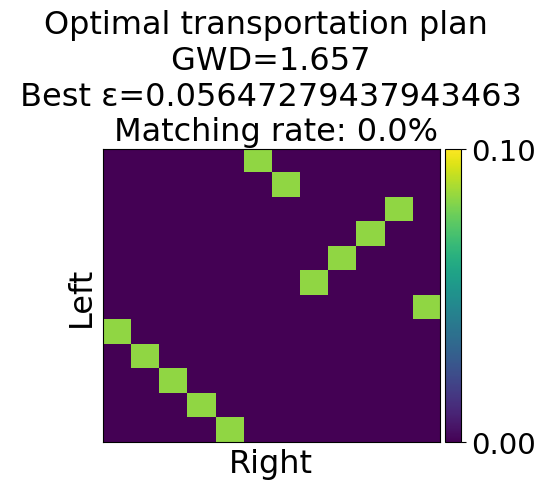

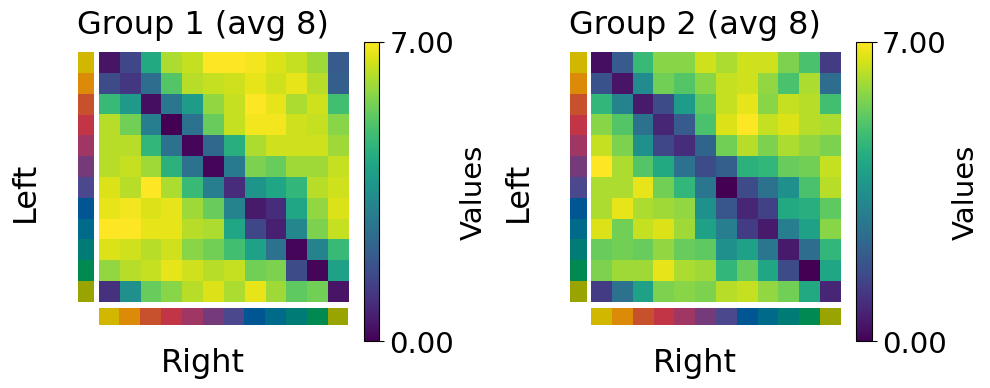

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.6313850355589193, Minimum GWD: 1.629


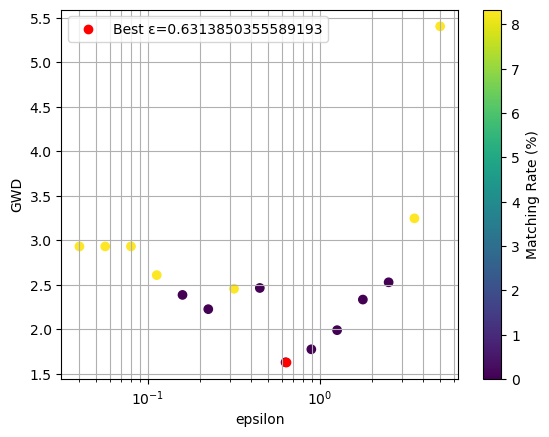

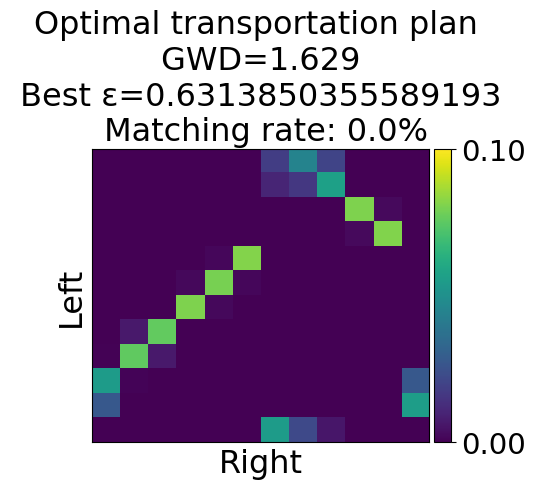

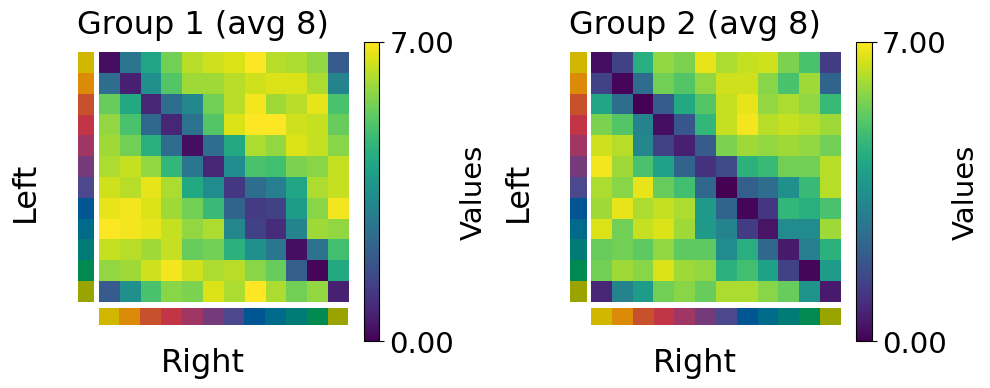

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.22436567925080053, Minimum GWD: 1.017


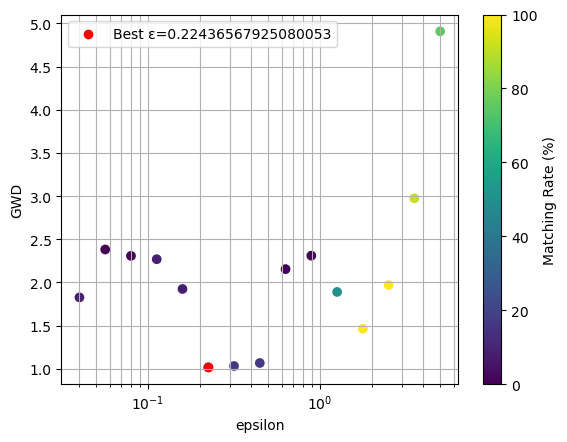

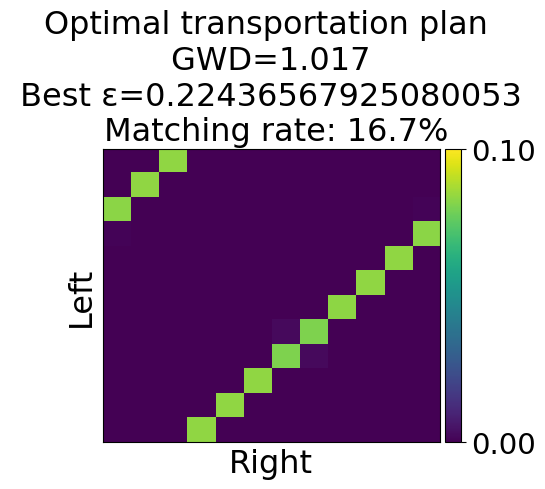

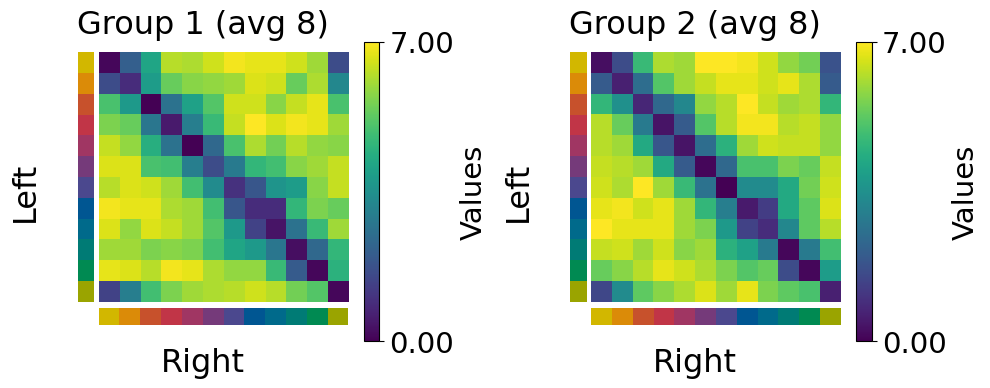

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.22436567925080053, Minimum GWD: 0.868


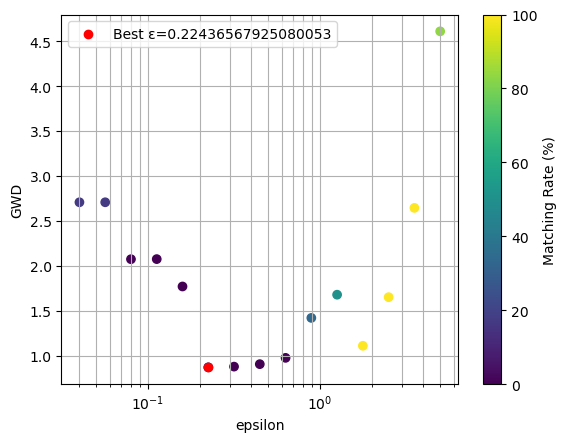

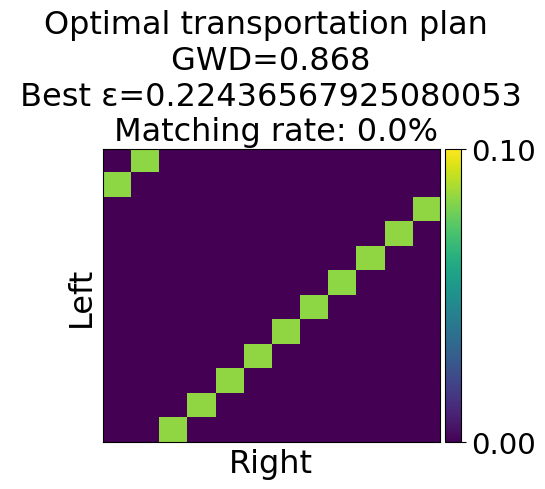

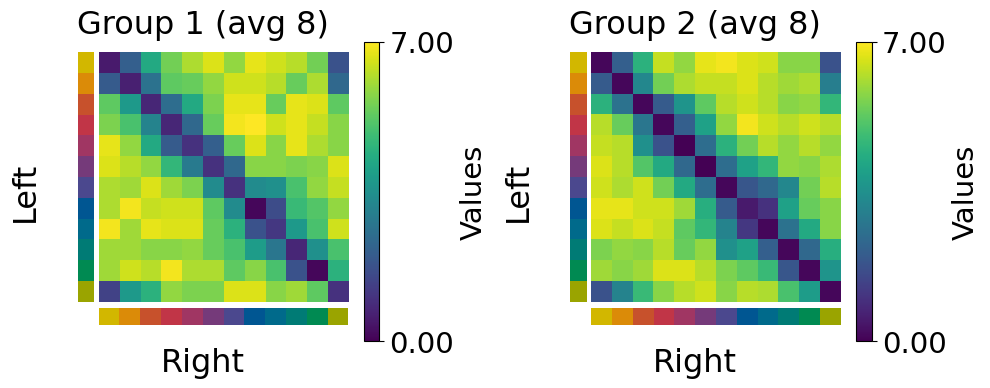

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.447213595499958, Minimum GWD: 0.807


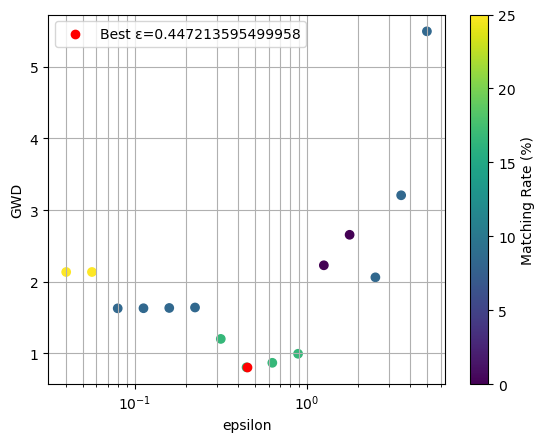

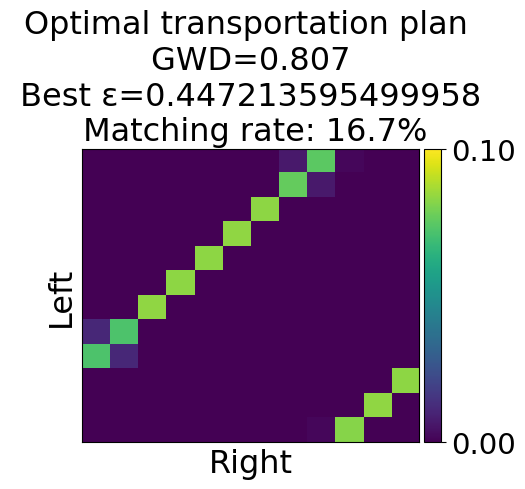

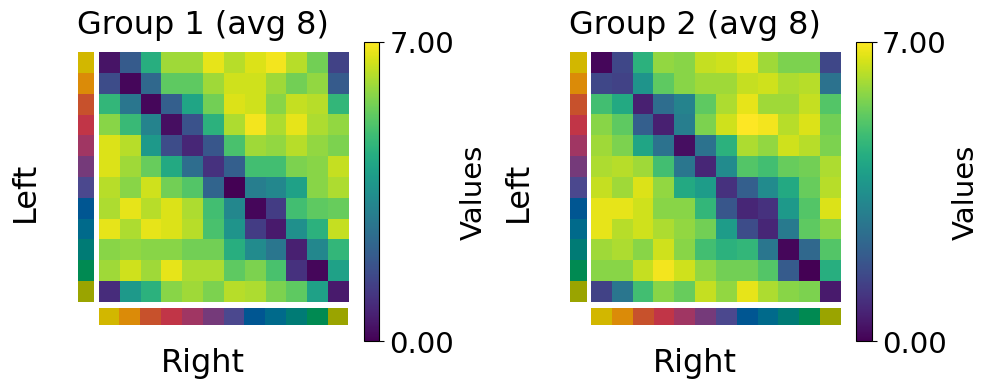

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.8914019321842716, Minimum GWD: 0.966


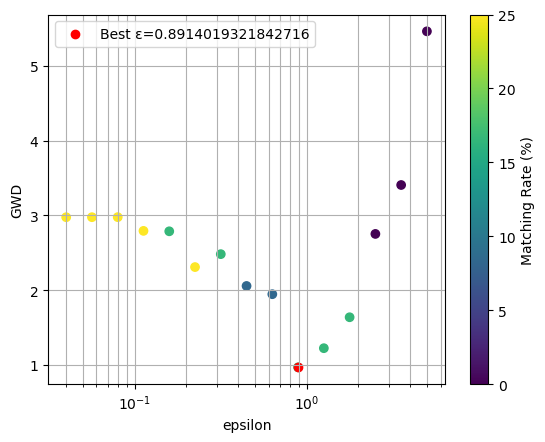

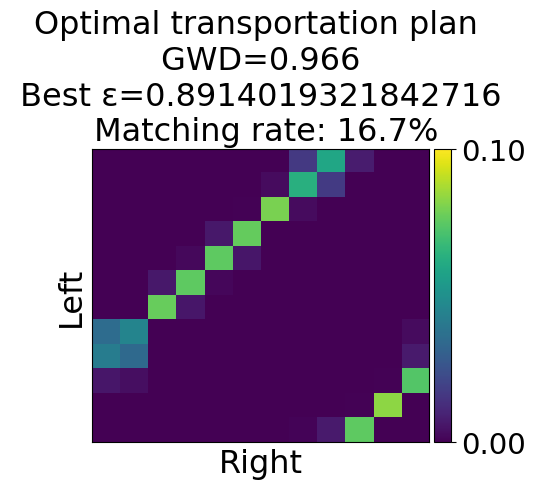

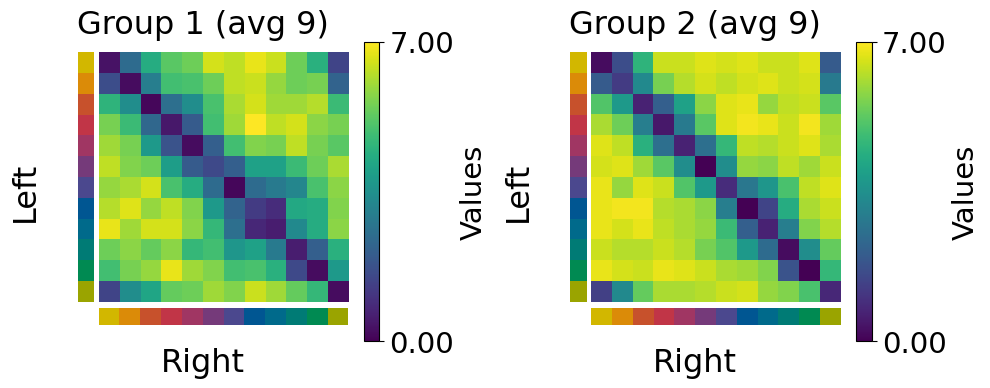

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.8914019321842716, Minimum GWD: 1.689


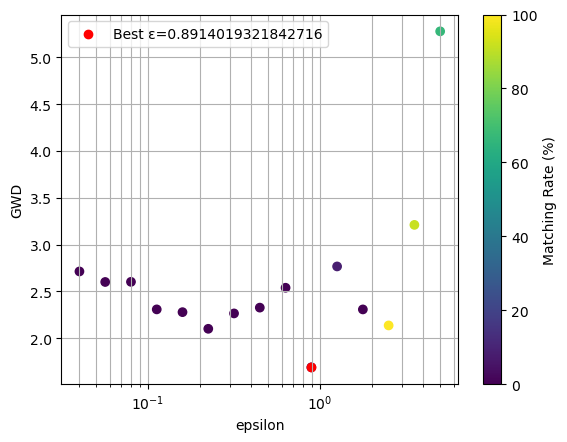

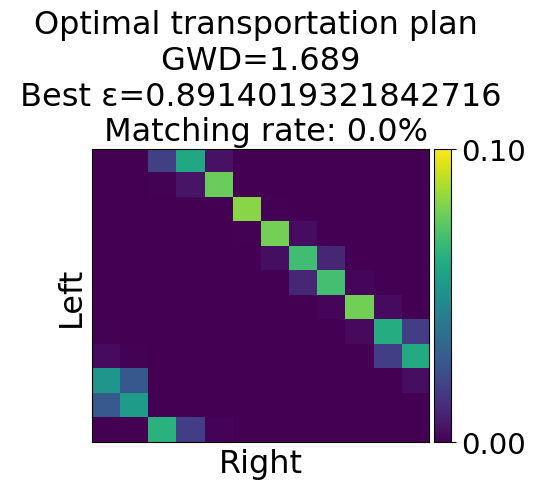

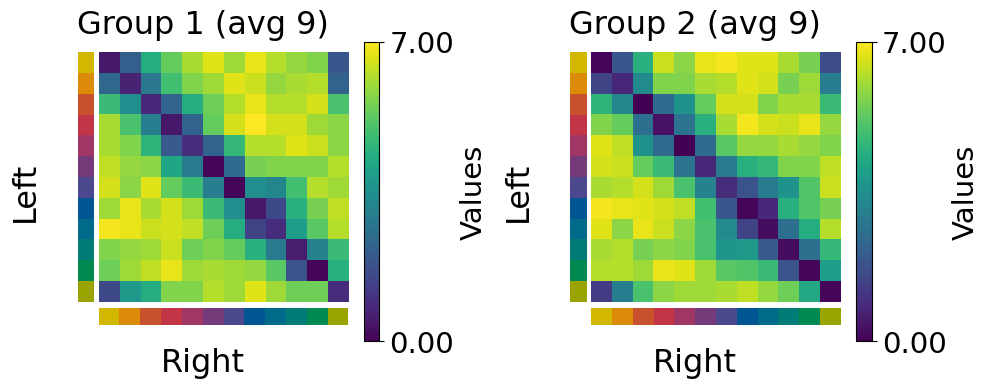

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.05647279437943463, Minimum GWD: 0.719


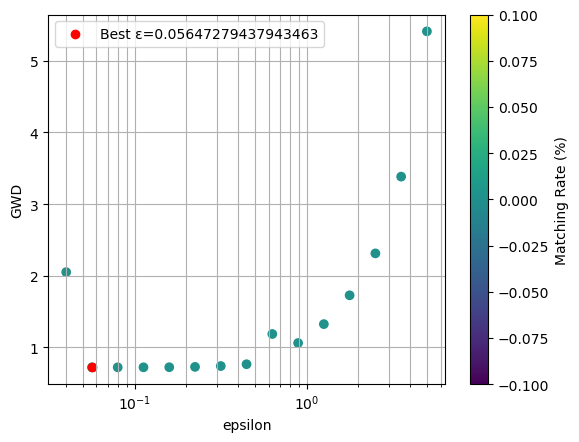

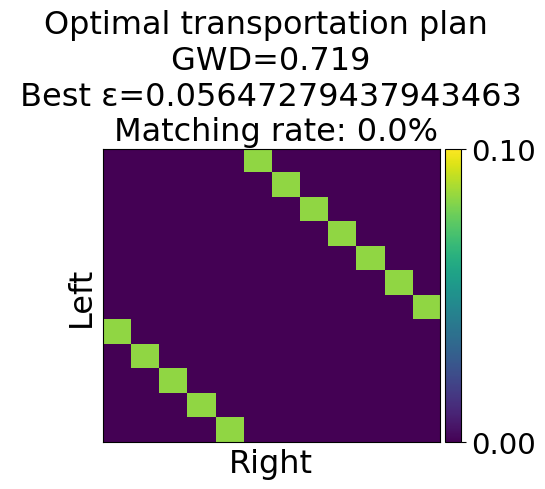

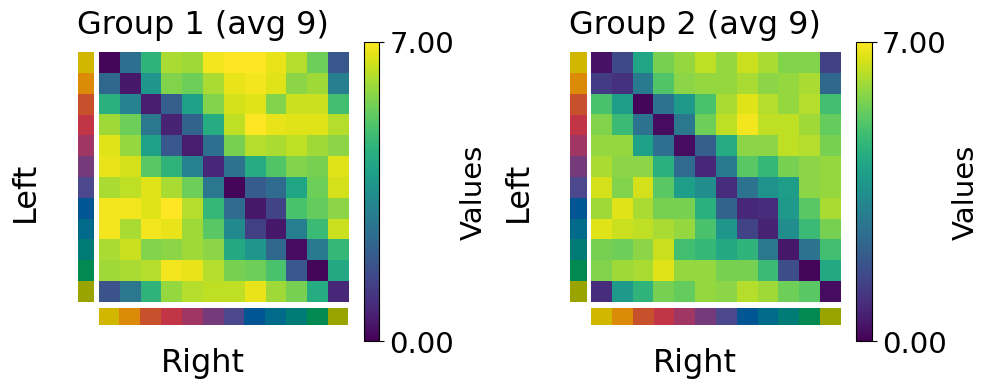

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.6313850355589193, Minimum GWD: 0.699


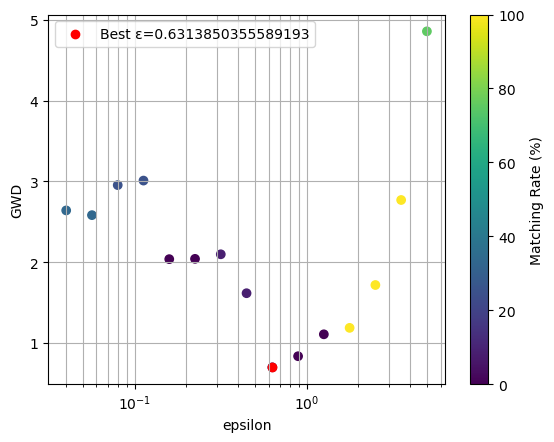

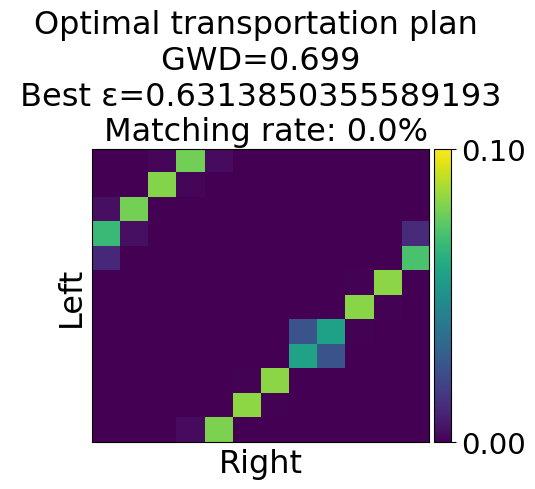

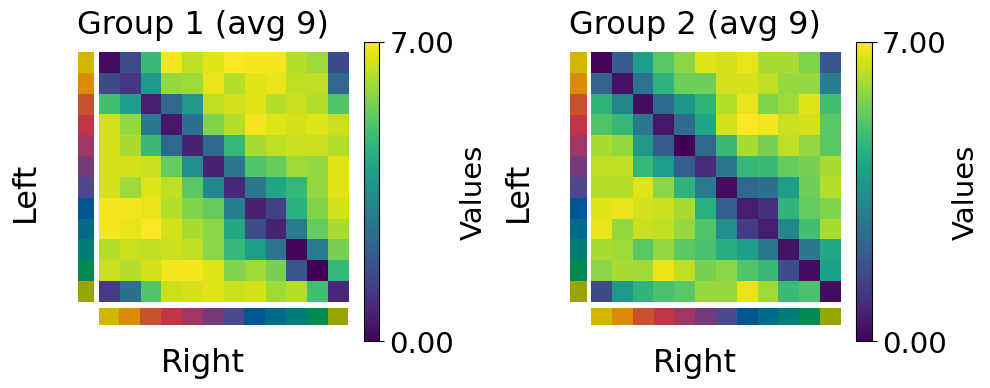

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.6313850355589193, Minimum GWD: 1.141


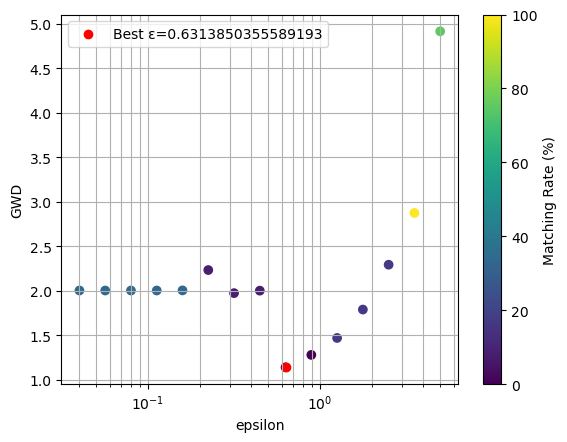

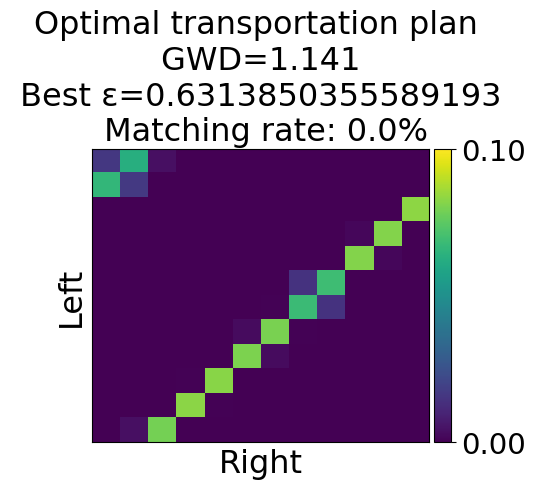

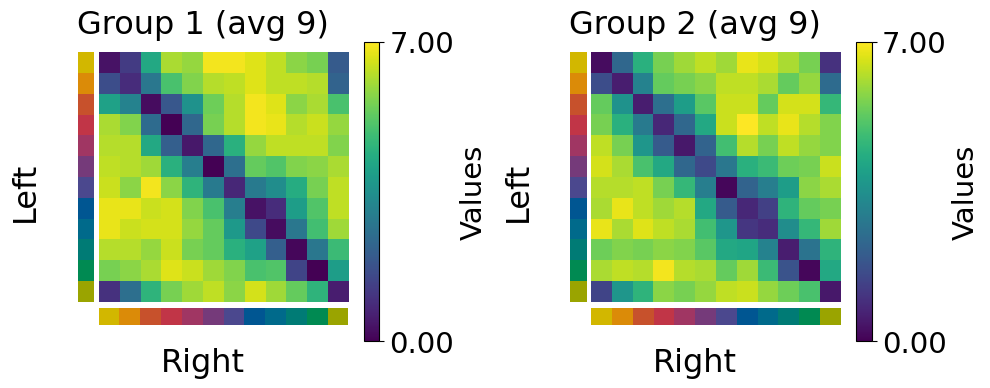

/opt/anaconda3/envs/condapreferencequalia/lib/python3.11/site-packages/ot/bregman/_sinkhorn.py:667: UserWarning: Sinkhorn did not converge. You might want to increase the number of iterations `numItermax` or the regularization parameter `reg`.
  warnings.warn(


Best epsilon: 0.447213595499958, Minimum GWD: 0.899


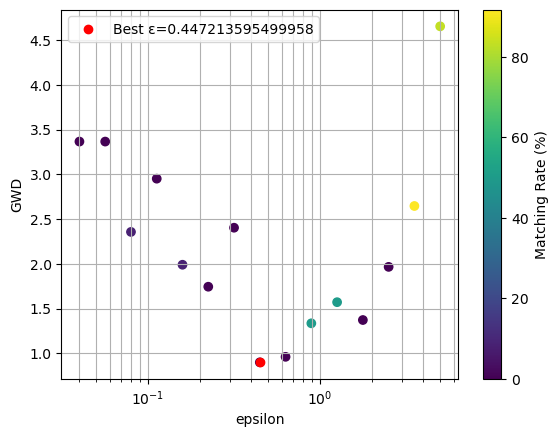

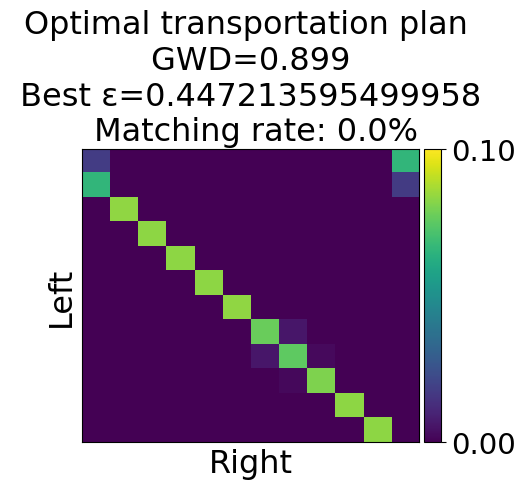

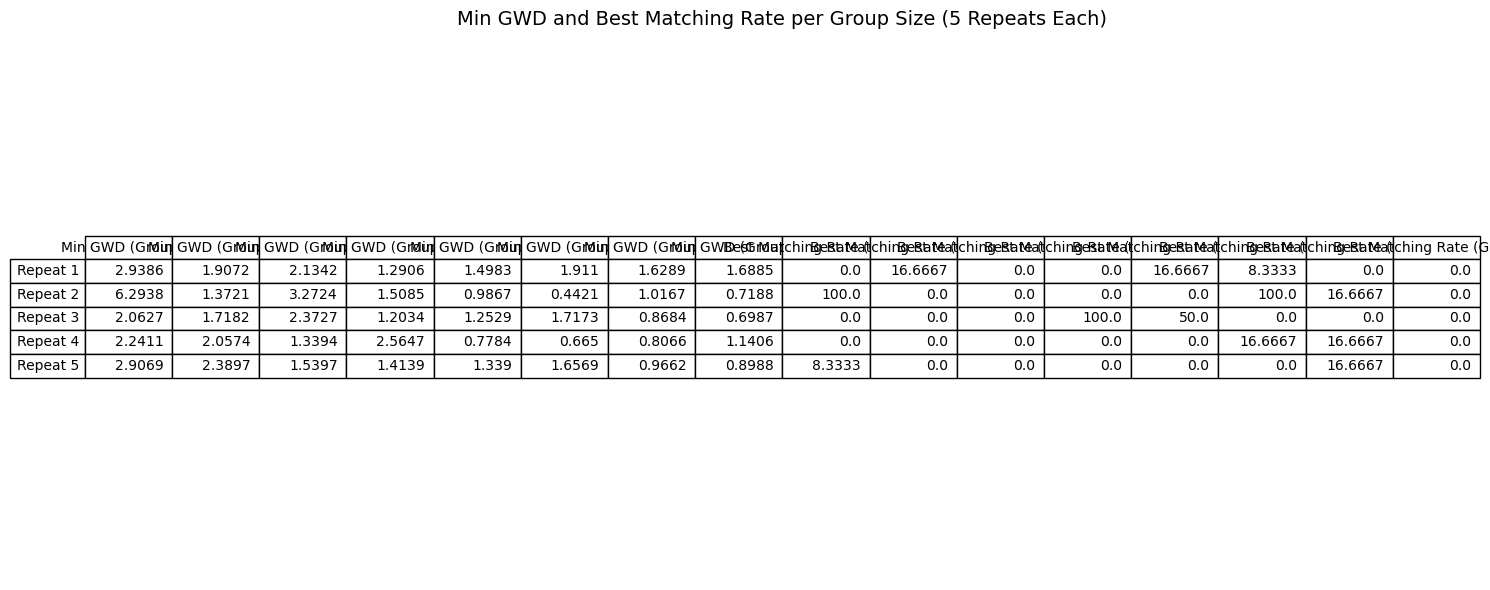

In [ ]:
num_subjects = len(subject_matrices_similarity_distance)
max_group_size = min(9, num_subjects // 2)

# GWOT configuration
n_eps = 15
eps_range = [0.04, 5]
epsilons = np.logspace(np.log10(eps_range[0]), np.log10(eps_range[1]), n_eps)

random.seed(42)
n_repeats = 5

# To store results
results = []

for group_size in range(2, max_group_size + 1):
    for repeat in range(n_repeats):
        # Randomly sample unique subjects
        sampled_indices = random.sample(range(num_subjects), 2 * group_size)
        group1_indices = sampled_indices[:group_size]
        group2_indices = sampled_indices[group_size:]

        group1_matrices = [subject_matrices_similarity_distance[i] for i in group1_indices]
        group2_matrices = [subject_matrices_similarity_distance[i] for i in group2_indices]
        avg_matrix1 = np.mean(group1_matrices, axis=0)
        avg_matrix2 = np.mean(group2_matrices, axis=0)

        # Optional: visualize
        show_heatmaps(
            vmin_val=0,
            vmax_val=7,
            matrices=[avg_matrix1, avg_matrix2],
            titles=[f"Group 1 (avg {group_size})", f"Group 2 (avg {group_size})"],
            nrows=1,
            ncols=2,
            cmap_name="viridis",
            cbar_label="Values",
            color_labels=unique_colours
        )

        # GWOT
        pair_of_preference = [avg_matrix1, avg_matrix2]
        OT_plan, gwds, matching_rates, min_gwd, best_matching_rate = GWD_and_plot(
            pair_of_preference[0], pair_of_preference[1], epsilons
        )

        # Store results
        results.append({
            "Group Size": group_size,
            "Repeat": repeat + 1,
            "Min GWD": min_gwd,
            "Best Matching Rate": best_matching_rate
        })

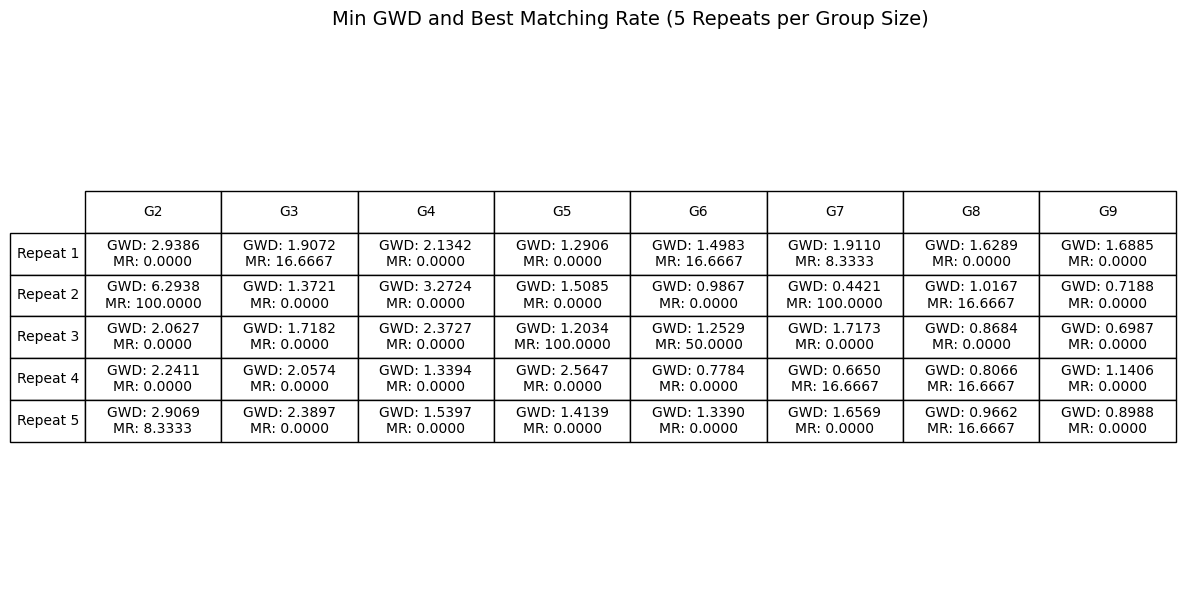

In [13]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Format cell values with GWD and MR together
results_df["Formatted"] = results_df.apply(
    lambda row: f"GWD: {row['Min GWD']:.4f}\nMR: {row['Best Matching Rate']:.4f}", axis=1
)

# Pivot table: rows are Repeats, columns are Group Sizes
formatted_table = results_df.pivot(index="Repeat", columns="Group Size", values="Formatted")
formatted_table.columns = [f"G{col}" for col in formatted_table.columns]  # Rename columns to G2, G3, ...

# Plot table using matplotlib
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')

tbl = ax.table(
    cellText=formatted_table.values,
    rowLabels=[f"Repeat {i}" for i in formatted_table.index],
    colLabels=formatted_table.columns,
    cellLoc='center',
    loc='center'
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)

tbl.scale(1.2, 2.2)  
plt.title("Min GWD and Best Matching Rate (5 Repeats per Group Size)", fontsize=14, pad=20)
plt.tight_layout()
plt.show()
